# Iteración 4: Retorno al Enfoque Micro-Biomecánico y Ablación de Varianza

Tras explorar alternativas arquitectónicas en la fase previa, esta cuarta iteración plantea una pausa analítica para resolver una incógnita fundamental del proyecto: ¿el fracaso del enfoque micro-biomecánico en la Iteración 1 fue consecuencia de una premisa teórica defectuosa, o simplemente se debió a las limitaciones de los modelos de visión utilizados en aquel momento? Para responder a esta cuestión mediante una prueba de control rigurosa, se propone un retorno deliberado a la estrategia original, pero actualizando el motor de extracción visual a la arquitectura más reciente y capaz de **Qwen-3.5-VL 8B** (bajo cuantización `Q6_K`).

El diseño experimental de esta fase exige mantener inalterados los *prompts* de la primera iteración para garantizar una comparativa limpia. De este modo, el sistema vuelve a evaluar dos formulaciones de extracción de memoria. La primera, de carácter abierto, exige al VLM redactar descripciones técnicas libres sobre detalles anatómicos finos, como el ángulo exacto de aproximación, la inclinación del tronco o la zona precisa de contacto entre la bota y el balón. La segunda formulación, de carácter cerrado, obliga al modelo a encasillar esas mismas variables en un catálogo estricto de etiquetas discretas (por ejemplo, `erguido`, `retrasado` o `interior`), buscando homogeneizar la representación semántica y reducir la variabilidad lingüística entre diferentes vídeos.

El conducto de inferencia mantiene su naturaleza modular, delegando la interpretación táctica de esta memoria visual a un Modelo de Lenguaje puro, concretamente **Qwen3.5-9B**. Sin embargo, la integración de estos modelos más densos impuso restricciones operativas en el entorno de ejecución local, obligando a desactivar los modos de razonamiento extendido del LLM para evitar un consumo de *tokens* que hiciera inviable el procesamiento del conjunto de datos en tiempos razonables. El LLM, alimentado con las nuevas descripciones micro-biomecánicas, debe emitir un veredicto en el espacio relativo del jugador (`CRUZADO`, `CENTRAL` o `ABIERTO`), que posteriormente el sistema mapeará a las coordenadas absolutas de la portería.

Como novedad metodológica respecto a la primera iteración, esta fase introduce un estudio de ablación dinámico sobre el formato cerrado. Tras una primera ejecución, el sistema audita la concentración de etiquetas generadas por el modelo de visión. Si una variable concreta (como, por ejemplo, la flexión de la rodilla) recae en la misma categoría dominante en más del 75% de las muestras, se considera que carece de capacidad discriminativa efectiva. A partir de este umbral empírico, se diseña una versión "podada" del *prompt*, eliminando de raíz estas variables de baja varianza para comprobar si una representación más condensada y con menos ruido redundante facilita el razonamiento del LLM.

En esencia, la cuarta iteración actúa como un test de estrés para la viabilidad de la micro-biomecánica en el análisis deportivo mediante visión artificial. Si los nuevos modelos logran estabilizar las descripciones anatómicas milimétricas y mejoran la precisión final, se validará el enfoque original. Si, por el contrario, la alta dimensionalidad de las articulaciones sigue generando ambigüedad a pesar de la mejora de los pesos neuronales, se confirmará empíricamente que la debilidad reside en la propia naturaleza de la señal visual extraída de retransmisiones estándar en dos dimensiones.

### 1. Configuración Base y Procesamiento Visual

Para llevar a cabo esta cuarta iteración y realizar una prueba de control sobre la hipótesis inicial del trabajo, se actualizó la infraestructura del modelo de visión a **Qwen-3.5-VL 8B** y el módulo de inferencia textual a **Qwen3.5-9B**. Para garantizar una comparativa científica rigurosa y directa respecto a la primera iteración, se reutilizó íntegramente el bloque fundacional encargado del procesamiento visual. Las rutinas de carga de datos, el cálculo dinámico de las cajas delimitadoras, la sincronización temporal respecto al impacto y la codificación de fotogramas en base64 se mantuvieron inalteradas, asegurando que la única variable modificada en el experimento fuera la capacidad deductiva intrínseca de la nueva generación de modelos fundacionales.

In [1]:
import cv2
import base64
import os
import time
import pandas as pd
from openai import OpenAI
import matplotlib.pyplot as plt
import numpy as np

# CONFIGURACIÓN
# 8192
CLIENT = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")

BASE_DIR = r'C:\Users\david\OneDrive\Desktop\TFT_LLMPenalties2026'
CSV_ORIGINAL_PATH = os.path.join(BASE_DIR, 'labeled_frames_cuttedvids.csv')
CSV_GROUPED_PATH = os.path.join(BASE_DIR, 'labeled_frames_grouped.csv')
VIDEOS_DIR = os.path.join(BASE_DIR, 'modified_videos')
RESULTADOS_MEMORIA_PATH = os.path.join(BASE_DIR, 'memorias_visuales.csv')
DF_ORIGINAL = pd.read_csv(CSV_ORIGINAL_PATH)

def resize_keep_aspect_ratio(image, target_size=384):
    """ Escala una imagen sin deformarla y añade franjas negras """
    old_h, old_w = image.shape[:2]
    ratio = min(target_size / old_w, target_size / old_h)
    new_w = int(old_w * ratio)
    new_h = int(old_h * ratio)
    
    if ratio < 1.0:
        interp = cv2.INTER_AREA
    else:
        interp = cv2.INTER_CUBIC
        
    resized = cv2.resize(image, (new_w, new_h), interpolation=interp)
    
    delta_w = target_size - new_w
    delta_h = target_size - new_h
    top, bottom = delta_h // 2, delta_h - (delta_h // 2)
    left, right = delta_w // 2, delta_w - (delta_w // 2)
    
    padded_img = cv2.copyMakeBorder(resized, top, bottom, left, right, 
                                    cv2.BORDER_CONSTANT, value=[0, 0, 0])
    return padded_img

def encode_image_to_base64(frame):
    _, buffer = cv2.imencode('.jpg', frame, [int(cv2.IMWRITE_JPEG_QUALITY), 95])
    return base64.b64encode(buffer).decode('utf-8')

def get_correct_bbox(vid_data, frame_idx_modificado, target_frames=64):
    total_original_frames = len(vid_data)
    if total_original_frames == 0: return None
    if total_original_frames > target_frames:
        indice_real = frame_idx_modificado + (total_original_frames - target_frames)
    elif total_original_frames < target_frames:
        padding_size = target_frames - total_original_frames
        indice_real = 0 if frame_idx_modificado < padding_size else frame_idx_modificado - padding_size
    else:
        indice_real = frame_idx_modificado
    indice_real = min(indice_real, len(vid_data) - 1)
    return int(vid_data.iloc[indice_real]['BB_x']), int(vid_data.iloc[indice_real]['BB_y']), int(vid_data.iloc[indice_real]['BB_w']), int(vid_data.iloc[indice_real]['BB_h'])

def get_kick_frame_idx(vid_data, target_frames=64):
    total_orig = len(vid_data)
    kick_rows = vid_data[vid_data['kick_frame'] == 1]
    kick_orig = int(kick_rows.iloc[0]['frame_id']) if len(kick_rows) > 0 else total_orig // 2

    if total_orig > target_frames:
        kick_mod = kick_orig - (total_orig - target_frames)
    elif total_orig < target_frames:
        kick_mod = kick_orig + (target_frames - total_orig)
    else:
        kick_mod = kick_orig

    total_mod = min(total_orig, target_frames)
    return max(0, min(total_mod - 1, kick_mod))

def crop_frame(frame, vid_data, frame_idx, target_frames=64, pad=100):
    """ Recorta el jugador usando el Bounding Box y añade un margen de padding dinámico """
    bbox = get_correct_bbox(vid_data, frame_idx, target_frames=target_frames)
    if bbox:
        x, y, w, h = bbox
        H, W, _ = frame.shape
        x1, y1 = max(0, x - pad), max(0, y - pad)
        x2, y2 = min(W, x + w + pad), min(H, y + h + pad)
        return resize_keep_aspect_ratio(frame[y1:y2, x1:x2], target_size=384)
    return resize_keep_aspect_ratio(frame, target_size=512)

def sample_frames_from_range(frames, vid_data, start, end, n_samples):
    segment = list(range(start, end))
    if not segment: return []
    if len(segment) <= n_samples:
        indices = segment
    else:
        indices = [segment[int(i * len(segment) / n_samples)] for i in range(n_samples)]
    return [encode_image_to_base64(crop_frame(frames[i], vid_data, i)) for i in indices]

def extract_frames_by_phase(video_path, vid_data, n_carrera_1=4, n_carrera_2=6, n_impacto=3, n_seguimiento=6):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret: break
        frames.append(frame)
    cap.release()
    if not frames: return None

    kick_idx = get_kick_frame_idx(vid_data)
    total = len(frames)
    
    fase_carrera_1   = (0, max(1, kick_idx - 12))
    
    fase_carrera_2   = (max(1, kick_idx - 12), max(2, kick_idx - 1))
    
    fase_impacto     = (max(0, kick_idx - 1), min(total, kick_idx + 2))
    
    fase_seguimiento = (min(total, kick_idx + 2), total)

    return {
        "carrera_1":     sample_frames_from_range(frames, vid_data, *fase_carrera_1,   n_carrera_1),
        "carrera_2":     sample_frames_from_range(frames, vid_data, *fase_carrera_2,   n_carrera_2),
        "impacto":       sample_frames_from_range(frames, vid_data, *fase_impacto,     n_impacto),
        "seguimiento":   sample_frames_from_range(frames, vid_data, *fase_seguimiento, n_seguimiento),
        "kick_idx":      kick_idx,
        "total":         total,
        "n_carrera_1":   n_carrera_1,
        "n_carrera_2":   n_carrera_2,
        "n_impacto":     n_impacto,
        "n_seguimiento": n_seguimiento,
    }

### 2. Generación de la Memoria Visual: Enfoque Micro-Biomecánico (Variante Abierta)

Para evaluar el impacto de la actualización tecnológica sobre el rendimiento de las extracciones textuales libres, se implementó este bloque de código destinado a generar la primera variante abierta de la memoria visual. La arquitectura de este módulo es directamente homóloga a la utilizada en la Iteración 1, conservando intactas las dependencias de la API local y la estructura modular que divide el análisis del gesto en cuatro secuencias independientes (carrera inicial, plantada, impacto y seguimiento) antes de ensamblarlas en un único texto continuo.

Para garantizar que el nuevo modelo multimodal (Qwen-3.5-VL 8B) focalice su capacidad deductiva sobre el mismo espectro de características finas que su predecesor, se reutilizaron fielmente los *prompts* originales diseñados para el enfoque micro-biomecánico. Se instruyó explícitamente a la red neuronal para que priorizara la detección de señales altamente específicas —como el ángulo exacto de aproximación, la orientación milimétrica del pie de apoyo o la rotación relativa entre la pelvis y el torso— prohibiéndole expresamente el uso de descripciones narrativas, tácticas o macro-gestuales. Con esta configuración, se busca comprobar empíricamente si la fragilidad y ambigüedad documental experimentada durante la primera iteración era un síntoma de una capacidad de visión por computador inmadura o si, independientemente de la potencia del modelo, estas variables finas resultan estructuralmente inobservables dadas las limitaciones de resolución y perspectiva de la cámara.

In [2]:
import pandas as pd

def construir_memoria_estructurada(desc_carrera_1, desc_carrera_2, desc_impacto, desc_seguimiento):
    def limpiar(texto):
        return texto.strip() if texto else "No se pudo extraer información."

    return (
        f"--- FASE DE CARRERA INICIAL ---\n{limpiar(desc_carrera_1)}\n\n"
        f"--- FASE DE PLANTA/APOYO ---\n{limpiar(desc_carrera_2)}\n\n"
        f"--- FASE DE IMPACTO ---\n{limpiar(desc_impacto)}\n\n"
        f"--- FASE DE SEGUIMIENTO E INERCIA ---\n{limpiar(desc_seguimiento)}"
    )


def generar_memoria_visual(video_path, vid_data, pierna):
    fases = extract_frames_by_phase(video_path, vid_data)
    if not fases:
        return None

    def llamar_vlm(frames_b64, prompt_sistema, prompt_usuario):
        if not frames_b64:
            return "No hay frames."

        content = [{"type": "text", "text": prompt_usuario}]
        for img in frames_b64:
            content.append({
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{img}"}
            })

        try:
            response = CLIENT.chat.completions.create(
                model="local-model",
                messages=[
                    {"role": "system", "content": prompt_sistema},
                    {"role": "user", "content": content}
                ],
                max_tokens=800,
                temperature=0.3
            )
            return response.choices[0].message.content
        except Exception as e:
            return f"Error visual: {e}"

    pierna = pierna.lower().strip()
    pie_apoyo = "izquierdo" if pierna == "derecha" else "derecho"

    prompt_sistema_fase = f"""
Eres un analista biomecánico de visión artificial especializado en penaltis de fútbol.

Analizas a un jugador pateando un penalti con la pierna {pierna.upper()}, visto desde una cámara diagonal trasera.

Tu tarea es describir únicamente variables micro-biomecánicas visualmente observables en la secuencia de imágenes. 
Debes actuar como un observador técnico de geometría corporal, no como un narrador, un comentarista ni un analista táctico.

Debes priorizar estas señales:
- ángulo de aproximación al balón,
- lateralidad visible de la entrada respecto al balón,
- orientación del pie de apoyo,
- posición relativa del pie de apoyo respecto al balón,
- inclinación del tronco,
- orientación relativa de tronco y pelvis,
- configuración visible de la pierna de golpeo,
- zona aparente de contacto bota-balón,
- seguimiento inmediato y dirección inicial de la pierna tras el impacto.

Reglas obligatorias:
- Describe solo lo que esté respaldado visualmente por los fotogramas.
- No inventes detalles anatómicos ocultos, fuerzas, ni trayectorias no visibles.
- No uses biomecánica teórica para rellenar huecos.
- No hables de la intención del lanzador ni predigas directamente la dirección final del disparo.
- Evita comentarios generales como "el jugador parece preparado" o "la postura es natural".
- Si una señal es ambigua por perspectiva, desenfoque, oclusión o resolución, exprésalo con fórmulas como "parece", "aparenta", "difícil de apreciar" o "(estimación)".
- Usa vocabulario técnico, concreto y breve.
- Prioriza la descripción de relaciones espaciales finas entre segmentos corporales y balón.
""".strip()

    prompt_carrera_1 = """
Observa esta secuencia correspondiente a la fase inicial de la carrera de aproximación.

Describe en texto técnico y breve únicamente estos aspectos micro-biomecánicos:

1. Ángulo de aproximación (APA):
Indica desde qué lado visual del balón entra el jugador y describe si la trayectoria hacia el balón parece recta, ligeramente diagonal o marcadamente diagonal.

2. Asimetría espacial de la entrada:
Describe si la aproximación genera una entrada visual más cerrada o más abierta respecto al eje balón-portería.
No interpretes la intención del disparo; limítate a la geometría visible.

3. Alineación tronco-cadera durante la aproximación:
Describe si el tronco se mantiene relativamente vertical o si presenta una inclinación anterior progresiva.
Indica también si pelvis y tronco aparentan mantenerse alineados o si ya se aprecia una ligera pre-rotación.

4. Configuración micro-postural de la carrera:
Describe si la base corporal aparenta ser compacta o abierta y si el centro corporal parece mantenerse alto o descender ligeramente al acercarse al balón.

5. Preparación del apoyo:
Describe cualquier señal visible de precolocación corporal relevante para la futura plantada, especialmente en la relación entre la pierna de golpeo, el eje del tronco y la llegada al balón.

No añadas conclusiones sobre la dirección del tiro.
No conviertas esta fase en una descripción macro-gestual.
""".strip()

    prompt_carrera_2 = f"""
Observa la secuencia correspondiente a la fase de planta/apoyo inmediatamente previa al impacto.

Describe en texto técnico y breve únicamente estos aspectos:

1. Dirección final de llegada:
Confirma desde qué lado visual se produce la llegada al balón en la plantada y si la entrada final mantiene una geometría recta, ligeramente diagonal o marcadamente diagonal.

2. Orientación del pie de apoyo ({pie_apoyo.upper()}):
Describe hacia dónde parece apuntar la punta del pie de apoyo.
Distingue, si es posible, entre orientación hacia delante, ligeramente abierta hacia fuera o claramente abierta hacia fuera.
Ten en cuenta la distorsión de la cámara diagonal trasera y no sobreafirmes si la imagen es ambigua.

3. Posición del pie de apoyo respecto al balón:
Describe si el pie de apoyo parece quedar retrasado, alineado o adelantado respecto al centro del balón.
Indica también, si puede apreciarse, si queda más próximo o más separado lateralmente del balón.

4. Inclinación del tronco en la plantada:
Describe si el tronco cae hacia delante sobre el balón, permanece relativamente vertical o presenta inclinación lateral apreciable.

5. Orientación pre-impacto de pelvis y torso:
Describe si el bloque pélvico-torácico parece alineado hacia delante o si aparenta una apertura hacia el exterior.
Si pelvis y torso no parecen coincidir exactamente, descríbelo.

6. Asimetría corporal previa al golpeo:
Describe si la disposición apoyo-golpeo aparenta una organización más cerrada, neutra o abierta desde el punto de vista espacial.

No hables todavía del seguimiento posterior.
No uses lenguaje narrativo.
""".strip()

    prompt_impacto = f"""
Observa exclusivamente el frame exacto del contacto pie-balón.

Describe en texto técnico y breve únicamente estos aspectos micro-biomecánicos:

1. Inclinación del tronco en impacto:
Indica si el tronco cae hacia delante, se mantiene relativamente vertical o aparenta una inclinación posterior o lateral.

2. Rotación relativa de tronco y pelvis:
Fíjate en el bloque tronco-pelvis en el instante de golpeo.
Describe si parecen orientados hacia delante o si visualmente se aprecian abiertos hacia el exterior.
Si uno de los dos segmentos aparenta mayor rotación que el otro, indícalo.

3. Configuración articular visible de la pierna de golpeo ({pierna.upper()}):
Describe la disposición visible de cadera, rodilla y pie en el momento del contacto, pero solo en términos observables.
No inventes ángulos exactos si no pueden verse.

4. Zona aparente de contacto bota-balón:
Si la imagen lo permite, indica si el contacto parece producirse con la zona interna, central o externa de la bota.
Si no se aprecia bien, dilo explícitamente.

5. Relación entre apoyo e impacto:
Describe si el conjunto pie de apoyo - pelvis - pierna de golpeo aparenta una ejecución visualmente más cerrada, neutra o abierta.

6. Asimetría espacial en el instante crítico:
Describe si la organización corporal en el contacto parece favorecer una salida corporal alineada o una apertura lateral visible.
No deduzcas la dirección final del balón.

No expliques biomecánica teórica.
No extraigas conclusiones tácticas.
""".strip()

    prompt_seguimiento = f"""
Observa únicamente la fase inmediatamente posterior al impacto.

Describe en texto técnico y breve únicamente estos aspectos:

1. Dirección inicial del seguimiento de la pierna de golpeo ({pierna.upper()}):
Describe si la pierna continúa hacia delante, cruza hacia dentro o sale abierta hacia fuera tras el impacto.

2. Dirección visible de la rodilla tras el golpeo:
Indica si la rodilla parece orientarse hacia el frente, hacia dentro o mantenerse abierta hacia fuera.

3. Continuidad de la rotación pélvica:
Describe si la pelvis aparenta seguir acompañando el gesto hacia delante o si el seguimiento conserva una apertura lateral visible.

4. Cierre o apertura inmediata del gesto:
Describe si el seguimiento inmediato sugiere un cierre cruzado del gesto o una continuidad más abierta hacia el exterior.

5. Altura relativa del pie de golpeo:
Describe si el pie asciende claramente, se mantiene a media altura o queda relativamente bajo.

No describas la inercia general del cuerpo salvo que sea necesaria para explicar la dirección de la pierna de golpeo.
No conviertas esta fase en un análisis macro-gestual.
""".strip()

    desc_carrera_1 = llamar_vlm(
        fases["carrera_1"],
        prompt_sistema_fase,
        prompt_carrera_1
    )

    desc_carrera_2 = llamar_vlm(
        fases["carrera_2"],
        prompt_sistema_fase,
        prompt_carrera_2
    )

    desc_impacto = llamar_vlm(
        fases["impacto"],
        prompt_sistema_fase,
        prompt_impacto
    )

    desc_seguimiento = llamar_vlm(
        fases["seguimiento"],
        prompt_sistema_fase,
        prompt_seguimiento
    )

    return {
        "final": construir_memoria_estructurada(
            desc_carrera_1,
            desc_carrera_2,
            desc_impacto,
            desc_seguimiento
        )
    }

### 3. Generación de la Memoria Visual: Enfoque Micro-Biomecánico (Variante Cerrada)

Para materializar la segunda variante de esta fase de control metodológico, se implementó el bloque de código correspondiente al *prompt* cerrado, recuperando íntegramente la estructura categórica diseñada durante la primera iteración. Al igual que en la variante abierta analizada previamente, el motor de extracción de fotogramas, la codificación de las imágenes y la concatenación temporal de las secuencias permanecieron inalterados, delegando todo el procesamiento visual al nuevo modelo Qwen-3.5-VL 8B. El objetivo central de esta ejecución fue comprobar empíricamente si la rigidez impuesta por un sistema de clasificación discreta, que obliga a la red neuronal a elegir etiquetas predefinidas para cada característica micro-biomecánica, lograba generar resultados más estables, precisos y discriminativos al estar impulsado por una arquitectura multimodal más avanzada.

Para restringir por completo la variabilidad lingüística y forzar una salida textual perfectamente homogénea, se reutilizaron las estrictas instrucciones de sistema originales, las cuales prohíben al modelo añadir explicaciones narrativas, justificaciones de contexto o razonamientos tácticos. A través de los *prompts* específicos elaborados para la carrera, la plantada, el impacto y el seguimiento, se obligó a la red a clasificar variables milimétricas —como el grado de inclinación del tronco, la separación lateral del apoyo o la rotación aislada de la pelvis— encasillándolas en categorías rígidas preestablecidas. Para evitar que el sistema colapsara u ofreciera falsos positivos ante la ambigüedad visual inherente a la resolución de los vídeos, se instruyó a la red neuronal para utilizar la etiqueta de incertidumbre exclusivamente en aquellos casos donde la señal resultara materialmente imposible de evaluar, garantizando así la construcción de una memoria visual altamente estructurada y predecible de cara a la etapa de inferencia posterior.

In [5]:
import pandas as pd

def construir_memoria_estructurada(desc_carrera_1, desc_carrera_2, desc_impacto, desc_seguimiento):
    def limpiar(texto):
        return texto.strip() if texto else "No se pudo extraer información."

    return (
        f"--- FASE DE CARRERA INICIAL ---\n{limpiar(desc_carrera_1)}\n\n"
        f"--- FASE DE PLANTA/APOYO ---\n{limpiar(desc_carrera_2)}\n\n"
        f"--- FASE DE IMPACTO ---\n{limpiar(desc_impacto)}\n\n"
        f"--- FASE DE SEGUIMIENTO E INERCIA ---\n{limpiar(desc_seguimiento)}"
    )


def generar_memoria_visual(video_path, vid_data, pierna):
    fases = extract_frames_by_phase(video_path, vid_data)
    if not fases:
        return None

    def llamar_vlm(frames_b64, prompt_sistema, prompt_usuario):
        if not frames_b64:
            return "No hay frames."

        content = [{"type": "text", "text": prompt_usuario}]
        for img in frames_b64:
            content.append({
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{img}"}
            })

        try:
            response = CLIENT.chat.completions.create(
                model="local-model",
                messages=[
                    {"role": "system", "content": prompt_sistema},
                    {"role": "user", "content": content}
                ],
                max_tokens=800,
                temperature=0.3
            )
            return response.choices[0].message.content
        except Exception as e:
            return f"Error visual: {e}"

    pierna = pierna.lower().strip()
    pie_apoyo = "izquierdo" if pierna == "derecha" else "derecho"

    prompt_sistema_fase = f"""
Eres un analista biomecánico de visión artificial especializado en penaltis de fútbol.

Analizas a un jugador pateando un penalti con la pierna {pierna.upper()}, visto desde una cámara diagonal trasera.

Tu tarea es clasificar únicamente variables micro-biomecánicas visualmente observables en la secuencia de imágenes.
Debes actuar como un clasificador técnico de geometría corporal.

Variables prioritarias:
- ángulo de aproximación,
- lateralidad visible de entrada,
- orientación del pie de apoyo,
- posición relativa del pie de apoyo respecto al balón,
- inclinación del tronco,
- orientación de pelvis y torso,
- configuración visible de la pierna de golpeo,
- zona aparente de contacto bota-balón,
- dirección inicial del seguimiento tras el impacto.

Reglas obligatorias:
- Usa solo las etiquetas permitidas.
- Devuelve exactamente el formato pedido.
- No añadas explicaciones, justificaciones ni texto extra.
- No hables de intención de disparo.
- No predigas la dirección final del balón.
- Si la imagen es ambigua, usa la categoría más probable visualmente.
- Solo usa INCIERTO cuando la señal sea realmente imposible de clasificar.
""".strip()

    prompt_carrera_1 = """
Observa esta secuencia correspondiente a la fase inicial de la carrera de aproximación.

Clasifica usando exactamente este formato:

APA: <etiqueta>
ENTRADA_LATERAL: <etiqueta>
TRONCO_CARRERA: <etiqueta>
PRE_ROTACION_TRONCO_PELVIS: <etiqueta>
BASE_CARRERA: <etiqueta>

Etiquetas permitidas:

APA = FRONTAL | LIGERAMENTE_DIAGONAL | MARCADAMENTE_DIAGONAL | INCIERTO
ENTRADA_LATERAL = IZQUIERDA_VISUAL | DERECHA_VISUAL | CENTRADA | INCIERTO
TRONCO_CARRERA = ERGUIDO | LIGERAMENTE_INCLINADO | CLARAMENTE_INCLINADO | INCIERTO
PRE_ROTACION_TRONCO_PELVIS = CERRADA | NEUTRA | ABIERTA | INCIERTO
BASE_CARRERA = COMPACTA | NEUTRA | ABIERTA | INCIERTO

Devuelve solo esas cinco líneas.
""".strip()

    prompt_carrera_2 = f"""
Observa la secuencia correspondiente a la fase de planta/apoyo inmediatamente previa al impacto.

Clasifica usando exactamente este formato:

LLEGADA_FINAL: <etiqueta>
ORIENTACION_PIE_APOYO: <etiqueta>
POSICION_PIE_APOYO_BALON: <etiqueta>
SEPARACION_LATERAL_APOYO: <etiqueta>
TRONCO_PLANTADA: <etiqueta>
ORIENTACION_TRONCO_PELVIS_PREIMPACTO: <etiqueta>

Etiquetas permitidas:

LLEGADA_FINAL = FRONTAL | LIGERAMENTE_DIAGONAL | MARCADAMENTE_DIAGONAL | INCIERTO
ORIENTACION_PIE_APOYO = HACIA_DELANTE | LIGERAMENTE_ABIERTO | MUY_ABIERTO | INCIERTO
POSICION_PIE_APOYO_BALON = RETRASADO | ALINEADO | ADELANTADO | INCIERTO
SEPARACION_LATERAL_APOYO = CERCANO | INTERMEDIO | SEPARADO | INCIERTO
TRONCO_PLANTADA = ERGUIDO | HACIA_DELANTE | INCLINADO_LATERAL | INCIERTO
ORIENTACION_TRONCO_PELVIS_PREIMPACTO = CERRADA | NEUTRA | ABIERTA | INCIERTO

Devuelve solo esas seis líneas.
Ten en cuenta que el pie de apoyo es el {pie_apoyo.upper()}.
""".strip()

    prompt_impacto = f"""
Observa exclusivamente el frame exacto del contacto pie-balón.

Clasifica usando exactamente este formato:

TRONCO_IMPACTO: <etiqueta>
ROTACION_TRONCO: <etiqueta>
ROTACION_PELVIS: <etiqueta>
PIERNA_GOLPEO_CONFIG: <etiqueta>
CONTACTO_BOTA: <etiqueta>
RELACION_APOYO_GOLPEO: <etiqueta>

Etiquetas permitidas:

TRONCO_IMPACTO = HACIA_DELANTE | VERTICAL | HACIA_ATRAS_O_LATERAL | INCIERTO
ROTACION_TRONCO = CERRADA | NEUTRA | ABIERTA | INCIERTO
ROTACION_PELVIS = CERRADA | NEUTRA | ABIERTA | INCIERTO
PIERNA_GOLPEO_CONFIG = CERRADA | NEUTRA | ABIERTA | INCIERTO
CONTACTO_BOTA = INTERIOR | CENTRAL | EXTERIOR | INCIERTO
RELACION_APOYO_GOLPEO = CERRADA | NEUTRA | ABIERTA | INCIERTO

Devuelve solo esas seis líneas.
La pierna de golpeo es la {pierna.upper()}.
""".strip()

    prompt_seguimiento = f"""
Observa únicamente la fase inmediatamente posterior al impacto.

Clasifica usando exactamente este formato:

DIRECCION_SEGUIMIENTO: <etiqueta>
DIRECCION_RODILLA: <etiqueta>
ROTACION_PELVIS_POST: <etiqueta>
CIERRE_FINAL_GESTO: <etiqueta>
ALTURA_PIE_FINAL: <etiqueta>

Etiquetas permitidas:

DIRECCION_SEGUIMIENTO = HACIA_DELANTE | CRUZADO_HACIA_DENTRO | ABIERTO_HACIA_FUERA | INCIERTO
DIRECCION_RODILLA = FRENTE | HACIA_DENTRO | HACIA_FUERA | INCIERTO
ROTACION_PELVIS_POST = HACIA_DELANTE | NEUTRA | ABIERTA_HACIA_FUERA | INCIERTO
CIERRE_FINAL_GESTO = CERRADO | NEUTRO | ABIERTO | INCIERTO
ALTURA_PIE_FINAL = BAJA | MEDIA | ALTA | INCIERTO

Devuelve solo esas cinco líneas.
La pierna de golpeo es la {pierna.upper()}.
""".strip()

    desc_carrera_1 = llamar_vlm(
        fases["carrera_1"],
        prompt_sistema_fase,
        prompt_carrera_1
    )

    desc_carrera_2 = llamar_vlm(
        fases["carrera_2"],
        prompt_sistema_fase,
        prompt_carrera_2
    )

    desc_impacto = llamar_vlm(
        fases["impacto"],
        prompt_sistema_fase,
        prompt_impacto
    )

    desc_seguimiento = llamar_vlm(
        fases["seguimiento"],
        prompt_sistema_fase,
        prompt_seguimiento
    )

    return {
        "final": construir_memoria_estructurada(
            desc_carrera_1,
            desc_carrera_2,
            desc_impacto,
            desc_seguimiento
        )
    }

### 4. Ejecución del VLM y Generación de Memorias Visuales

Para orquestar la ejecución masiva del nuevo modelo multimodal y automatizar la generación de las memorias visuales micro-biomecánicas, se reutilizó íntegramente el motor de procesamiento en lote diseñado en la primera iteración, conservando intactas sus rutinas de extracción dinámica, persistencia estructurada en disco y reanudación automática frente a posibles interrupciones del servidor local.

In [3]:
df_agrupado = pd.read_csv(CSV_GROUPED_PATH)
procesados_memoria = set()

if os.path.exists(RESULTADOS_MEMORIA_PATH):
    df_existente = pd.read_csv(RESULTADOS_MEMORIA_PATH)
    if 'vid_ID' in df_existente.columns:
        procesados_memoria = set(df_existente['vid_ID'])

videos_pendientes = [v for v in df_agrupado['vid_ID'].unique() if v not in procesados_memoria][:300]

print(f"Videos pendientes por procesar en este lote: {len(videos_pendientes)}")

for vid_id in videos_pendientes:
    print(f"--- Procesando Vídeo: {vid_id} ---")

    fila_video = df_agrupado[df_agrupado['vid_ID'] == vid_id].iloc[0]
    vid_data_original = DF_ORIGINAL[DF_ORIGINAL['vid_ID'] == vid_id].sort_values(by='frame_id').reset_index(drop=True)
    video_path = os.path.join(VIDEOS_DIR, f"{vid_id}.mp4")

    pierna = "derecha" if fila_video['kicker_foot'] == 0 else "izquierda"
    memoria_dict = generar_memoria_visual(video_path, vid_data_original, pierna)

    if memoria_dict:

        nuevo_registro = pd.DataFrame([{
            'vid_ID': vid_id, 
            'kicker_foot': pierna, 
            'memoria_generada': memoria_dict['final']
        }])

        nuevo_registro.to_csv(
            RESULTADOS_MEMORIA_PATH, 
            mode='a', 
            header=not os.path.exists(RESULTADOS_MEMORIA_PATH), 
            index=False
        )
        print(f"Memoria descriptiva de {vid_id} guardada con éxito.\n")

        time.sleep(1)
    else:
        print(f"Error procesando el vídeo {vid_id}, se saltará.\n")

Videos pendientes por procesar en este lote: 300
--- Procesando Vídeo: v38_p13_diag ---
Memoria descriptiva de v38_p13_diag guardada con éxito.

--- Procesando Vídeo: v38_p14_diag ---
Memoria descriptiva de v38_p14_diag guardada con éxito.

--- Procesando Vídeo: v38_p15_diag ---
Memoria descriptiva de v38_p15_diag guardada con éxito.

--- Procesando Vídeo: v38_p16_diag ---
Memoria descriptiva de v38_p16_diag guardada con éxito.

--- Procesando Vídeo: v39_p1_diag ---
Memoria descriptiva de v39_p1_diag guardada con éxito.

--- Procesando Vídeo: v39_p2_diag ---
Memoria descriptiva de v39_p2_diag guardada con éxito.

--- Procesando Vídeo: v39_p3_diag ---
Memoria descriptiva de v39_p3_diag guardada con éxito.

--- Procesando Vídeo: v39_p4_diag ---
Memoria descriptiva de v39_p4_diag guardada con éxito.

--- Procesando Vídeo: v39_p5_diag ---
Memoria descriptiva de v39_p5_diag guardada con éxito.

--- Procesando Vídeo: v39_p6_diag ---
Memoria descriptiva de v39_p6_diag guardada con éxito.

---

### 5. Inferencia Final mediante LLM: Evaluación de la Memoria Abierta

Para procesar las descripciones libres generadas por el nuevo modelo visual y obtener la predicción de la dirección final del disparo, se reutilizó íntegramente la arquitectura del *prompt* abierto diseñado durante la primera iteración. Al conservar la estructura de instrucciones, las reglas dinámicas de lateralidad espacial y el formato de salida estructurado, se garantiza que la comparativa empírica entre el modelo original y Qwen3.5-9B sea completamente justa, evaluando únicamente la capacidad intrínseca del nuevo LLM para interpretar señales micro-biomecánicas. 

Para adaptar el flujo de código a las particularidades arquitectónicas de este nuevo modelo de lenguaje y optimizar los tiempos de ejecución locales, se implementó una técnica de prellenado o *pre-filling* en el historial de mensajes de la API. Dado que la familia Qwen3.5 incorpora un modo de razonamiento reflexivo que consume una cantidad excesiva de *tokens* internos antes de emitir la respuesta final, se forzó la desactivación de esta etapa inyectando manualmente las etiquetas de pensamiento cerradas y vacías (`<think>\n\n</think>`) directamente desde el rol del asistente virtual. Para recomponer la estructura de los datos tras este salto o bypass forzado, el *script* concatena el carácter de apertura del objeto JSON a la cadena de texto generada, logrando así una ejecución directa, determinista y eficiente sin alterar la rigurosidad del análisis táctico.

In [4]:
import json
import re
import os
import time
import pandas as pd
from openai import OpenAI


CLIENT_TEXT = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")
PREDICCIONES_PATH = 'predicciones_finales_abierto.csv'
RESULTADOS_MEMORIA_PATH = 'memorias_visuales.csv'

def predecir_direccion_llm(memoria_limpia, pierna):
    
    pierna_golpeo = pierna.lower()
    lado_cruzado = "izquierda" if pierna_golpeo == "derecha" else "derecha"
    lado_abierto = "derecha" if pierna_golpeo == "derecha" else "izquierda"
    lateralidad = "DIESTRO" if pierna_golpeo == "derecha" else "ZURDO"

    system_prompt = f"""Eres un experto en biomecánica deportiva y análisis de penaltis. Analiza el reporte de un modelo de visión (VLM) sobre un jugador {lateralidad} ejecutando un penalti. Predice la DIRECCIÓN FINAL del balón.

Vas a recibir una memoria visual ABIERTA, redactada en texto técnico por fases del gesto de golpeo.

La memoria puede contener información sobre:
- carrera inicial
- planta/apoyo
- impacto
- seguimiento e inercia

Para predecir la dirección final del balón, presta especial atención a:
- orientación del pie de apoyo
- posición del pie de apoyo respecto al balón
- orientación de pelvis y torso
- inclinación del tronco
- tipo de contacto bota-balón
- dirección inicial del seguimiento de la pierna de golpeo

REGLAS DE CLASIFICACIÓN PARA JUGADOR {lateralidad}:
- Tiro CENTRAL: la memoria sugiere apoyo alineado al balón, configuración relativamente frontal o neutra en el impacto, y ausencia de apertura o cierre claros.
- Tiro ABIERTO (hacia la {lado_abierto} del lanzador): la memoria sugiere apoyo abierto hacia fuera, pelvis o torso abiertos, contacto más compatible con interior del pie o seguimiento hacia fuera.
- Tiro CRUZADO (hacia la {lado_cruzado} del lanzador): la memoria sugiere apoyo retrasado, gesto más cerrado o seguimiento cruzando hacia dentro.

REGLAS PRÁCTICAS:
- Da más importancia a la fase de planta/apoyo y a la fase de impacto.
- Usa el seguimiento como pista adicional.
- Si hay señales mezcladas, escoge la dirección que parezca más consistente en el conjunto de la memoria.
- No inventes información que no esté escrita.

FORMATO DE SALIDA ESTRICTO (JSON):
{{
  "evaluacion_apoyo": "Resumen breve de lo que sugiere la planta/apoyo.",
  "evaluacion_impacto": "Resumen breve de lo que sugiere el impacto.",
  "evaluacion_seguimiento": "Resumen breve de lo que sugiere el seguimiento.",
  "justificacion_final": "Conclusión breve.",
  "prediccion": "Cruzado, Central o Abierto"
}}
"""

    try:
        response = CLIENT_TEXT.chat.completions.create(
        model="local-model",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": f"MEMORIA VISUAL ABIERTA:\n{memoria_limpia}\n\nAnaliza y genera el JSON estricto:"},
            {"role": "assistant", "content": "<think>\n\n</think>\n\n{"}
        ],
        max_tokens=800,
        temperature=0.1
    )
        
        texto_generado = "{" + response.choices[0].message.content.strip()
        json_limpio = re.sub(r'^```json\s*|\s*```$', '', texto_generado, flags=re.IGNORECASE | re.MULTILINE).strip()
        
        try:
            datos_json = json.loads(json_limpio)
            prediccion_limpia = datos_json.get("prediccion", "DESCONOCIDO").upper()
        except json.JSONDecodeError:
            coincidencias = re.findall(r'\b(CRUZADO|CENTRAL|ABIERTO)\b', texto_generado.upper())
            prediccion_limpia = coincidencias[-1] if coincidencias else "DESCONOCIDO"
            
        return texto_generado, prediccion_limpia
        
    except Exception as e:
        print(f"Error API: {e}")
        return None, "ERROR"

### 6. Inferencia Final mediante LLM: Evaluación de la Memoria Cerrada

Para ejecutar la fase deductiva sobre la segunda variante de esta iteración, se implementó el módulo de inferencia correspondiente al *prompt* cerrado, recuperando íntegramente el sistema de evaluación discreta diseñado en la fase inicial del proyecto. Al mantener inalteradas las reglas de clasificación espacial basadas en la lateralidad del lanzador y el mapeo estricto de las etiquetas biomecánicas (como `LIGERAMENTE_ABIERTO`, `RETRASADO` o `CRUZADO_HACIA_DENTRO`), se garantiza una base de comparación metodológicamente pura frente a los resultados obtenidos por los modelos de la generación anterior.

Para adaptar el motor de inferencia a las especificidades técnicas de Meta Qwen3.5-9B y maximizar la eficiencia del entorno de ejecución local, se mantuvo la misma técnica de optimización de recursos implementada en la variante abierta. Mediante la inyección de la directiva `/no_think` en el *prompt* del sistema y el prellenado o *bypass* de las etiquetas de razonamiento (`<think>\n\n</think>\n\n{`) en el historial del asistente, se bloquea la costosa fase de generación reflexiva interna del modelo. Esta decisión de implementación técnica resulta vital para viabilizar el procesamiento completo del *dataset*, garantizando que el modelo devuelva la estructura JSON de forma directa y determinista basándose exclusivamente en el cruce de las etiquetas categóricas proporcionadas por la memoria visual.

In [1]:
import json
import re
import os
import time
import pandas as pd
from openai import OpenAI


CLIENT_TEXT = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")
PREDICCIONES_PATH = 'predicciones_finales_cerrado.csv'
RESULTADOS_MEMORIA_PATH = 'memorias_visuales.csv'

def predecir_direccion_llm(memoria_limpia, pierna):
    
    pierna_golpeo = pierna.lower()
    lado_cruzado = "izquierda" if pierna_golpeo == "derecha" else "derecha"
    lado_abierto = "derecha" if pierna_golpeo == "derecha" else "izquierda"
    lateralidad = "DIESTRO" if pierna_golpeo == "derecha" else "ZURDO"

    system_prompt = f"""/no_think Eres un experto en biomecánica deportiva y análisis de penaltis. Analiza el reporte de un modelo de visión (VLM) sobre un jugador {lateralidad} ejecutando un penalti. Predice la DIRECCIÓN FINAL del balón.

Vas a recibir una memoria visual CERRADA, codificada mediante etiquetas biomecánicas por fases del gesto de golpeo.

La memoria puede contener etiquetas sobre:
- carrera inicial
- planta/apoyo
- impacto
- seguimiento e inercia

Para predecir la dirección final del balón, presta especial atención a:
- ORIENTACION_PIE_APOYO
- POSICION_PIE_APOYO_BALON
- ORIENTACION_TRONCO_PELVIS_PREIMPACTO
- TRONCO_IMPACTO
- ROTACION_TRONCO
- ROTACION_PELVIS
- CONTACTO_BOTA
- RELACION_APOYO_GOLPEO
- DIRECCION_SEGUIMIENTO
- DIRECCION_RODILLA
- CIERRE_FINAL_GESTO

REGLAS DE CLASIFICACIÓN PARA JUGADOR {lateralidad}:
- Tiro CENTRAL: predominan señales como ALINEADO, NEUTRA, CENTRAL o configuraciones poco abiertas y poco cerradas.
- Tiro ABIERTO (hacia la {lado_abierto} del lanzador): predominan señales como LIGERAMENTE_ABIERTO, MUY_ABIERTO, ABIERTA, HACIA_FUERA, ABIERTO_HACIA_FUERA o INTERIOR.
- Tiro CRUZADO (hacia la {lado_cruzado} del lanzador): predominan señales como RETRASADO, CERRADA, HACIA_DENTRO, CRUZADO_HACIA_DENTRO o cierre corporal.

REGLAS PRÁCTICAS:
- Da más importancia a las etiquetas de apoyo e impacto.
- Usa el seguimiento como apoyo final.
- Si hay conflicto entre etiquetas, escoge la tendencia dominante del conjunto.
- No inventes información que no esté en la memoria.

FORMATO DE SALIDA ESTRICTO (JSON):
{{
  "evaluacion_apoyo": "Resumen breve de las etiquetas de apoyo.",
  "evaluacion_impacto": "Resumen breve de las etiquetas de impacto.",
  "evaluacion_seguimiento": "Resumen breve de las etiquetas de seguimiento.",
  "justificacion_final": "Conclusión breve.",
  "prediccion": "Cruzado, Central o Abierto"
}}
"""

    try:
        response = CLIENT_TEXT.chat.completions.create(
        model="local-model",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": f"MEMORIA VISUAL CERRADA:\n{memoria_limpia}\n\nAnaliza y genera el JSON estricto:"},
            {"role": "assistant", "content": "<think>\n\n</think>\n\n{"}
        ],
        max_tokens=800,
        temperature=0.1
    )
        
        texto_generado = "{" + response.choices[0].message.content.strip()
        json_limpio = re.sub(r'^```json\s*|\s*```$', '', texto_generado, flags=re.IGNORECASE | re.MULTILINE).strip()
        
        try:
            datos_json = json.loads(json_limpio)
            prediccion_limpia = datos_json.get("prediccion", "DESCONOCIDO").upper()
        except json.JSONDecodeError:
            coincidencias = re.findall(r'\b(CRUZADO|CENTRAL|ABIERTO)\b', texto_generado.upper())
            prediccion_limpia = coincidencias[-1] if coincidencias else "DESCONOCIDO"
            
        return texto_generado, prediccion_limpia
        
    except Exception as e:
        print(f"Error API: {e}")
        return None, "ERROR"

### 7. Ejecución de la Inferencia y Guardado de Predicciones

Para orquestar de forma masiva la fase de inferencia lingüística y automatizar la persistencia de las predicciones finales, se reutilizó íntegramente el motor de procesamiento secuencial consolidado en las fases previas del proyecto. Al mantener intacta la lógica de este bloque, se garantiza que la lectura del archivo de memorias visuales, la comprobación de los registros ya analizados y el guardado iterativo en disco funcionen de manera robusta, protegiendo el progreso del experimento ante cualquier interrupción o límite de cuota en la ejecución local del modelo Qwen3.5-9B.

In [6]:
if not os.path.exists(RESULTADOS_MEMORIA_PATH):
    print(f"Error: No se ha encontrado el archivo {RESULTADOS_MEMORIA_PATH}")
else:
    df_memorias = pd.read_csv(RESULTADOS_MEMORIA_PATH)

    procesados_prediccion = set()
    if os.path.exists(PREDICCIONES_PATH):
        try:
            df_exist = pd.read_csv(PREDICCIONES_PATH)
            procesados_prediccion = set(df_exist['vid_ID'])
        except Exception:
            pass

    pendientes_prediccion = df_memorias[~df_memorias['vid_ID'].isin(procesados_prediccion)]

    if len(pendientes_prediccion) == 0:
        print("Todos los vídeos ya han sido procesados.")
    else:
        print(f"\nIniciando razonamiento táctico para {len(pendientes_prediccion)} vídeos...")

        for _, row in pendientes_prediccion.iterrows():
            vid_id = row['vid_ID']
            pierna_jugador = row['kicker_foot']
            print(f"--- Razonando tácticamente sobre: {vid_id} ---")
            
            texto_completo, etiqueta_limpia = predecir_direccion_llm(row['memoria_generada'], pierna_jugador)
            
            if texto_completo:
                pd.DataFrame([{
                    'vid_ID': vid_id,
                    'kicker_foot': pierna_jugador,
                    'prediccion_etiqueta': etiqueta_limpia,
                    'razonamiento_completo': texto_completo
                }]).to_csv(PREDICCIONES_PATH, mode='a', header=not os.path.exists(PREDICCIONES_PATH), index=False)
                
                print(f"Predicción extraída: {etiqueta_limpia}")
                time.sleep(0.5)


Iniciando razonamiento táctico para 641 vídeos...
--- Razonando tácticamente sobre: v1_p1_diag ---
Predicción extraída: CENTRAL
--- Razonando tácticamente sobre: v1_p2_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p3_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p4_diag ---
Predicción extraída: CENTRAL
--- Razonando tácticamente sobre: v1_p5_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p6_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p7_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p8_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p9_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p10_diag ---
Predicción extraída: CENTRAL
--- Razonando tácticamente sobre: v1_p11_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p12_diag ---
Predicción extraída: DESCONOCIDO
--- Ra

### 8. Módulo de Evaluación y Métricas

Para validar empíricamente los resultados obtenidos mediante el nuevo conjunto de modelos Qwen-3.5 y determinar si el retorno al paradigma micro-biomecánico arroja una mejora significativa respecto a la primera iteración, se reutilizó de forma íntegra la clase de evaluación estandarizada. Al conservar intactos los algoritmos de traducción espacial, la depuración de inconsistencias y el motor de renderizado de las matrices de confusión, se asegura una comparabilidad métrica absoluta entre los distintos experimentos, permitiendo aislar la capacidad deductiva de la red neuronal de cualquier posible artefacto de evaluación.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
)

class EvaluadorResultados:
    def __init__(self, labels_path="labeled_frames_grouped.csv"):
        self.labels_path = labels_path
        self.nombres_clases = ["Zona 1", "Zona 2", "Zona 3"]
        self.labels = [1, 2, 3]

    def _mapear_a_numero(self, row):
        """
        Mapeo dependiente de la pierna de golpeo para problema multiclase 1, 2 y 3:
        - Zona Central: CENTRAL/CENTRO -> 2
        - Diestro:  CRUZADO -> 1, ABIERTO -> 3
        - Zurdo:    CRUZADO -> 3, ABIERTO -> 1
        """
        pred = str(row["prediccion_etiqueta"]).strip().upper()
        pierna = str(row["kicker_foot"]).strip().lower()

        if pred in ["CENTRAL", "CENTRO"]:
            return 2

        if pierna == "derecha":
            if pred == "CRUZADO": return 1
            if pred == "ABIERTO": return 3
        elif pierna == "izquierda":
            if pred == "CRUZADO": return 3
            if pred == "ABIERTO": return 1

        return -1

    def evaluar(self, pred_path, sufijo_experimento):
        if not os.path.exists(pred_path):
            print(f"Error: no se ha encontrado '{pred_path}'.")
            return
        if not os.path.exists(self.labels_path):
            print(f"Error: no se ha encontrado '{self.labels_path}'.")
            return

        df_pred = pd.read_csv(pred_path)
        df_labels = pd.read_csv(self.labels_path)

        cols_pred_necesarias = {"vid_ID", "kicker_foot", "prediccion_etiqueta"}
        cols_labels_necesarias = {"vid_ID", "shoot_zone_grouped"}

        faltan_pred = cols_pred_necesarias - set(df_pred.columns)
        faltan_labels = cols_labels_necesarias - set(df_labels.columns)

        if faltan_pred:
            raise ValueError(f"Faltan columnas en {pred_path}: {sorted(faltan_pred)}")
        if faltan_labels:
            raise ValueError(f"Faltan columnas en {self.labels_path}: {sorted(faltan_labels)}")

        df_labels = df_labels[["vid_ID", "shoot_zone_grouped"]].dropna().copy()
        df_labels["shoot_zone_grouped"] = df_labels["shoot_zone_grouped"].astype(int)

        inconsistencias = df_labels.groupby("vid_ID")["shoot_zone_grouped"].nunique().reset_index(name="n_zonas_distintas")
        inconsistencias = inconsistencias[inconsistencias["n_zonas_distintas"] > 1]

        if not inconsistencias.empty:
            ejemplos = inconsistencias["vid_ID"].astype(str).tolist()[:10]
            raise ValueError(
                "Hay videos con más de una zona real distinta en labeled_frames_grouped.csv. "
                f"Ejemplos: {ejemplos}"
            )

        df_labels = df_labels.drop_duplicates(subset=["vid_ID"]).rename(columns={"shoot_zone_grouped": "zona_real"}).copy()
        df = df_pred.merge(df_labels, on="vid_ID", how="inner")

        if df.empty:
            raise ValueError("El merge entre predicciones y labels ha dado 0 filas.")

        df = df[df["zona_real"].isin([1, 2, 3])].copy()
        df["prediccion_numero"] = df.apply(self._mapear_a_numero, axis=1)
        
        df_validos = df[df["prediccion_numero"].isin([1, 2, 3])].copy()

        if df_validos.empty:
            print("No se encontraron predicciones válidas (ABIERTO/CRUZADO/CENTRAL) para evaluar.")
            return

        df_validos["acierto"] = df_validos["zona_real"] == df_validos["prediccion_numero"]

        y_real = df_validos["zona_real"].tolist()
        y_pred = df_validos["prediccion_numero"].tolist()

        accuracy = accuracy_score(y_real, y_pred)
        balanced_acc = balanced_accuracy_score(y_real, y_pred)
        f1_macro = f1_score(y_real, y_pred, average="macro", zero_division=0)
        f1_weighted = f1_score(y_real, y_pred, average="weighted", zero_division=0)
        precision_macro = precision_score(y_real, y_pred, average="macro", zero_division=0)
        recall_macro = recall_score(y_real, y_pred, average="macro", zero_division=0)

        print("\n" + "=" * 60)
        print(" EVALUACION MULTICLASE (ZONAS 1, 2 Y 3) ")
        print("=" * 60)
        print(f"Muestras evaluadas:           {len(df_validos)}")
        print(f"Accuracy:                     {accuracy * 100:.2f}%")
        print(f"Balanced accuracy:            {balanced_acc * 100:.2f}%")
        print(f"Precision macro:              {precision_macro * 100:.2f}%")
        print(f"Recall macro:                 {recall_macro * 100:.2f}%")
        print(f"F1 macro:                     {f1_macro * 100:.2f}%")
        print(f"F1 weighted:                  {f1_weighted * 100:.2f}%")

        n_invalidas = len(df) - len(df_validos)
        if n_invalidas > 0:
            print(f"Predicciones no válidas:      {n_invalidas}")

        print("\nResumen detallado de las predicciones:")
        display_df = df_validos[
            ["vid_ID", "kicker_foot", "zona_real", "prediccion_etiqueta", "prediccion_numero", "acierto"]
        ].copy()
        print(display_df.to_string(index=False))

        cm = confusion_matrix(y_real, y_pred, labels=self.labels)
        report = classification_report(y_real, y_pred, labels=self.labels, target_names=self.nombres_clases, output_dict=True, zero_division=0)
        df_report = pd.DataFrame(report).T

        especificidades = {}
        for i, clase in enumerate(self.labels):
            tp = cm[i, i]
            fn = cm[i, :].sum() - tp
            fp = cm[:, i].sum() - tp
            tn = cm.sum() - tp - fn - fp
            especificidad = tn / (tn + fp) if (tn + fp) > 0 else 0.0
            especificidades[clase] = especificidad

        resumen_clases = []
        for clase, nombre in zip(self.labels, self.nombres_clases):
            resumen_clases.append({
                "clase": nombre,
                "precision": df_report.loc[nombre, "precision"],
                "sensibilidad_recall": df_report.loc[nombre, "recall"],
                "f1": df_report.loc[nombre, "f1-score"],
                "soporte": int(df_report.loc[nombre, "support"]),
                "especificidad": especificidades[clase],
            })

        df_resumen_clases = pd.DataFrame(resumen_clases)

        print("\n" + "=" * 60)
        print(" METRICAS POR CLASE ")
        print("=" * 60)
        print(df_resumen_clases.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

        df_resumen_clases.to_csv(f"metricas_por_clase_llm_{sufijo_experimento}.csv", index=False)

        plt.figure(figsize=(7, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=self.nombres_clases, yticklabels=self.nombres_clases)
        plt.title(f"Matriz de Confusión - LLM {sufijo_experimento.upper()} (conteos absolutos)")
        plt.ylabel("Zona real")
        plt.xlabel("Predicción")
        plt.tight_layout()
        plt.savefig(f"matriz_confusion_llm_{sufijo_experimento}.png", dpi=300)
        plt.show()

        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm)

        plt.figure(figsize=(7, 6))
        sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=self.nombres_clases, yticklabels=self.nombres_clases, vmin=0, vmax=1)
        plt.title(f"Matriz de Confusión - LLM {sufijo_experimento.upper()} (normalizada por fila)")
        plt.ylabel("Zona real")
        plt.xlabel("Predicción")
        plt.tight_layout()
        plt.savefig(f"matriz_confusion_llm_{sufijo_experimento}_normalizada.png", dpi=300)
        plt.show()

RESULTADOS PROMPT ABIERTO


 EVALUACION MULTICLASE (ZONAS 1, 2 Y 3) 
Muestras evaluadas:           636
Accuracy:                     25.31%
Balanced accuracy:            28.99%
Precision macro:              29.43%
Recall macro:                 28.99%
F1 macro:                     24.79%
F1 weighted:                  24.99%
Predicciones no válidas:      5

Resumen detallado de las predicciones:
      vid_ID kicker_foot  zona_real prediccion_etiqueta  prediccion_numero  acierto
  v1_p1_diag     derecha          1             CENTRAL                  2    False
  v1_p2_diag     derecha          1             ABIERTO                  3    False
  v1_p3_diag     derecha          2             CENTRAL                  2     True
  v1_p4_diag     derecha          3             CENTRAL                  2    False
  v1_p5_diag     derecha          1             ABIERTO                  3    False
  v1_p6_diag     derecha          1             ABIERTO                  3    False
  v1_p7_diag     derecha          3       

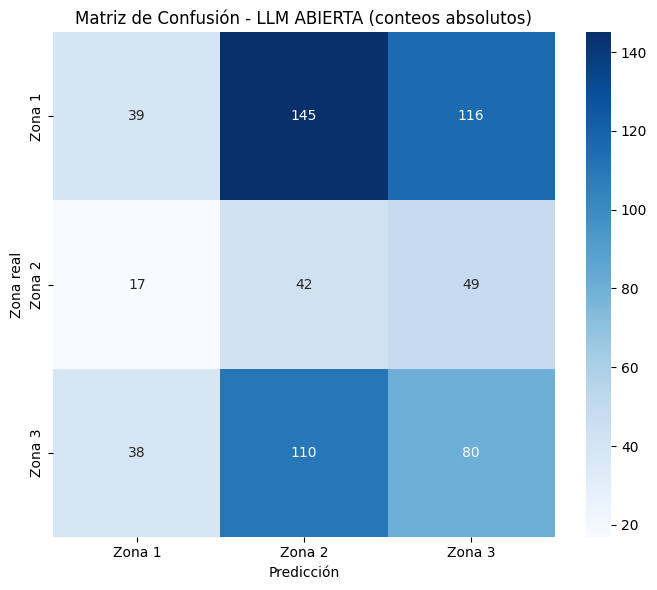

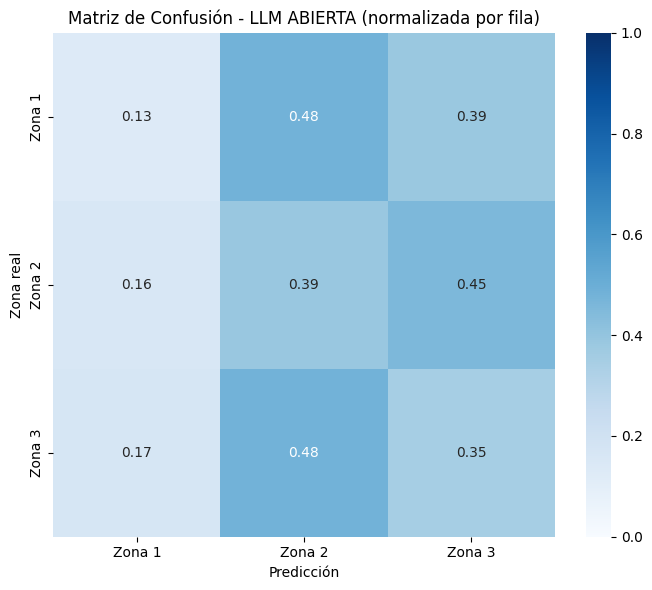

In [3]:
evaluador = EvaluadorResultados()
evaluador.evaluar("predicciones_finales_abierto.csv", "abierta")

RESULTADOS PROMPT CERRADO


 EVALUACION MULTICLASE (ZONAS 1, 2 Y 3) 
Muestras evaluadas:           618
Accuracy:                     31.39%
Balanced accuracy:            36.60%
Precision macro:              36.13%
Recall macro:                 36.60%
F1 macro:                     31.36%
F1 weighted:                  32.06%
Predicciones no válidas:      23

Resumen detallado de las predicciones:
      vid_ID kicker_foot  zona_real prediccion_etiqueta  prediccion_numero  acierto
  v1_p1_diag     derecha          1             ABIERTO                  3    False
  v1_p2_diag     derecha          1             CENTRAL                  2    False
  v1_p3_diag     derecha          2             ABIERTO                  3    False
  v1_p4_diag     derecha          3             CRUZADO                  1    False
  v1_p5_diag     derecha          1             CENTRAL                  2    False
  v1_p6_diag     derecha          1             ABIERTO                  3    False
  v1_p7_diag     derecha          3      

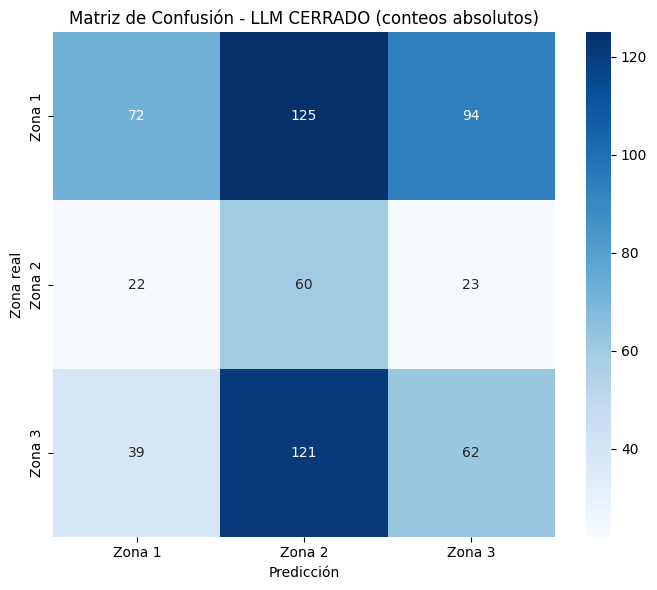

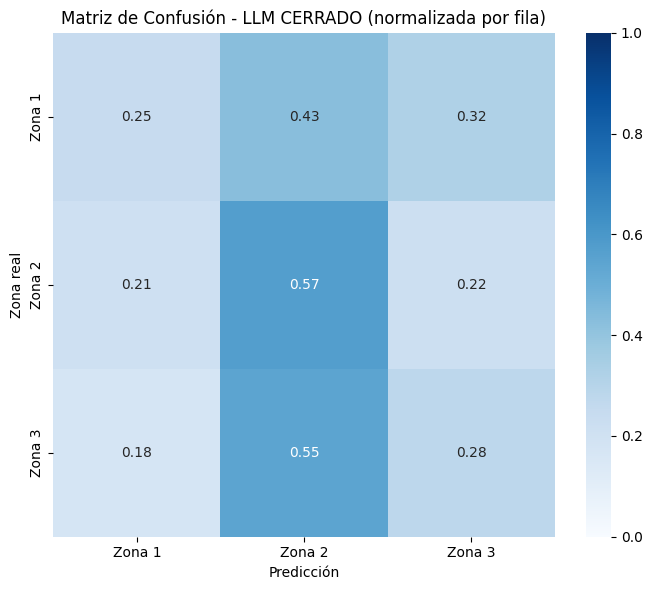

In [4]:
evaluador = EvaluadorResultados()
evaluador.evaluar("predicciones_finales_cerrado.csv", "cerrado")

### 9. Análisis de Concentración de Etiquetas y Ablación

Para llevar a cabo el estudio de ablación sobre la variante cerrada, tal y como se definió en el planteamiento metodológico de esta cuarta iteración, se reutilizó el módulo de análisis estadístico de etiquetas. Este *script* procesa las memorias visuales generadas por Qwen-3.5-VL 8B, extrae el formato estructurado de pares clave-valor y calcula la proporción matemática en la que cada variable se decanta por su categoría dominante. 

El objetivo de ejecutar este bloque de control es identificar empíricamente aquellas variables micro-biomecánicas que aportan poca diversidad informativa al sistema (es decir, aquellas cuya categoría dominante supera el 75% de las muestras procesadas). A partir de este diagnóstico cuantitativo y visual, se determina la poda de variables redundantes para construir una versión optimizada del *prompt* cerrado, evaluando si la eliminación del "ruido" categórico mejora la capacidad deductiva final del LLM.

,variable,categoria_dominante,frecuencia_dominante,porcentaje_dominante
21,ALTURA_PIE_FINAL,MEDIA,316,0.492980
7,POSICION_PIE_APOYO_BALON,RETRASADO,335,0.522621
2,TRONCO_CARRERA,ERGUIDO,370,0.577223
9,TRONCO_PLANTADA,ERGUIDO,379,0.591264
8,SEPARACION_LATERAL_APOYO,CERCANO,406,0.633385
10,ORIENTACION_TRONCO_PELVIS_PREIMPACTO,NEUTRA,410,0.639626
5,LLEGADA_FINAL,LIGERAMENTE_DIAGONAL,418,0.652106
16,RELACION_APOYO_GOLPEO,ABIERTA,430,0.670827
12,ROTACION_TRONCO,NEUTRA,435,0.678627
13,ROTACION_PELVIS,NEUTRA,435,0.678627


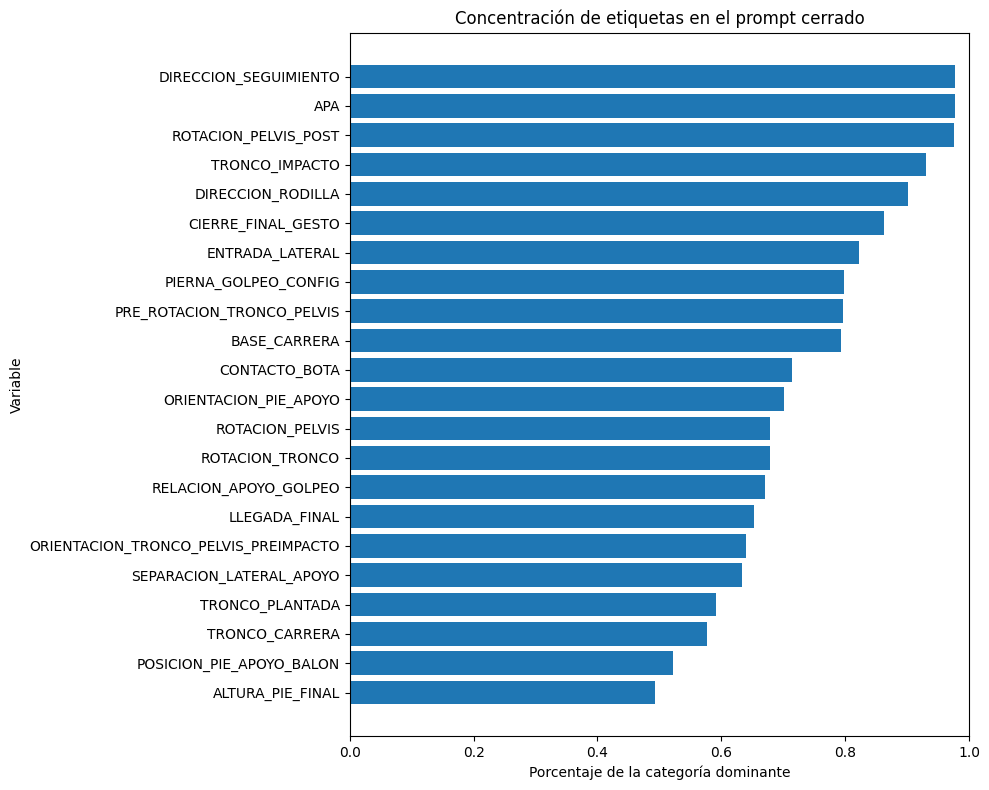

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt

CSV_CERRADO = "memorias_visuales_cerrado.csv"

def cargar_csv_memorias_cerrado(path_csv):
    if not os.path.exists(path_csv):
        raise FileNotFoundError(f"No existe el archivo: {path_csv}")

    df = pd.read_csv(path_csv)

    columnas_obligatorias = ["vid_ID", "kicker_foot", "memoria_generada"]
    faltan = [c for c in columnas_obligatorias if c not in df.columns]
    if faltan:
        raise ValueError(f"En {path_csv} faltan columnas obligatorias: {faltan}")

    return df.copy()


def extraer_etiquetas_desde_memoria(memoria):
    resultado = {}

    if not isinstance(memoria, str):
        return resultado

    for linea in memoria.splitlines():
        linea = linea.strip()

        if not linea:
            continue

        if linea.startswith("---") and linea.endswith("---"):
            continue

        if ":" in linea:
            clave, valor = linea.split(":", 1)
            clave = clave.strip()
            valor = valor.strip()

            if clave and valor:
                resultado[clave] = valor

    return resultado


def expandir_etiquetas_cerradas(df_cerrado):
    filas = []

    for _, row in df_cerrado.iterrows():
        base = {
            "vid_ID": row["vid_ID"],
            "kicker_foot": row["kicker_foot"],
        }

        etiquetas = extraer_etiquetas_desde_memoria(row["memoria_generada"])
        fila = {**base, **etiquetas}
        filas.append(fila)

    if not filas:
        return pd.DataFrame()

    return pd.DataFrame(filas)


def porcentaje_categoria_dominante(serie):
    serie = serie.dropna().astype(str).str.strip()
    if len(serie) == 0:
        return 0.0, "NA", 0

    conteo_abs = serie.value_counts(dropna=False)
    conteo_rel = serie.value_counts(normalize=True, dropna=False)

    categoria = conteo_rel.index[0]
    porcentaje = conteo_rel.iloc[0]
    frecuencia = conteo_abs.iloc[0]

    return porcentaje, categoria, frecuencia


def resumen_concentracion_cerrado(df_expandido):
    columnas_meta = {"vid_ID", "kicker_foot"}
    variables = [c for c in df_expandido.columns if c not in columnas_meta]

    filas = []
    for var in variables:
        pct, cat, freq = porcentaje_categoria_dominante(df_expandido[var])
        filas.append({
            "variable": var,
            "categoria_dominante": cat,
            "frecuencia_dominante": freq,
            "porcentaje_dominante": pct,
        })

    if not filas:
        return pd.DataFrame()

    return pd.DataFrame(filas).sort_values("porcentaje_dominante", ascending=True)


df_cerrado = cargar_csv_memorias_cerrado(CSV_CERRADO)
df_expandido = expandir_etiquetas_cerradas(df_cerrado)
tabla_concentracion = resumen_concentracion_cerrado(df_expandido)

display(tabla_concentracion)

plt.figure(figsize=(10, 8))
plt.barh(tabla_concentracion["variable"], tabla_concentracion["porcentaje_dominante"])
plt.xlabel("Porcentaje de la categoría dominante")
plt.ylabel("Variable")
plt.title("Concentración de etiquetas en el prompt cerrado")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig("concentracion_etiquetas_cerrado_iteracion1.png", dpi=300, bbox_inches="tight")
plt.show()

### 10. Generación de la Memoria Visual: Estudio de Ablación (Variante Cerrada Podada)

Como resultado directo del análisis estadístico de concentración de etiquetas, se implementó esta tercera variante visual, la cual actúa como un estudio de ablación sobre el *prompt* cerrado original. El objetivo de este código es evaluar si la eliminación de variables micro-biomecánicas redundantes —aquellas que el modelo Qwen-3.5-VL 8B colapsó repetidamente en una única categoría dominante en más del 75% de las muestras— permite generar una memoria visual más limpia, discriminativa y eficiente.

Las diferencias fundamentales entre este *prompt* podado y su versión original radican en la reducción drástica de las variables solicitadas en las secuencias inicial y final del gesto, centralizando la carga analítica en los instantes críticos del golpeo:

* **Fase de Carrera Inicial:** Se eliminaron casi todas las variables espaciales (como el ángulo de aproximación, la entrada lateral o la base de carrera), conservando exclusivamente la evaluación de la inclinación del tronco (`TRONCO_CARRERA`). El análisis previo demostró que el modelo clasificaba la inmensa mayoría de las aproximaciones de forma idéntica, aportando ruido en lugar de información útil.
* **Fase de Planta/Apoyo:** Esta fase se mantuvo prácticamente intacta, confirmando que la posición y orientación del pie de apoyo, así como la disposición de la cadera antes del impacto, conservan una alta variabilidad y son fundamentales para la estructura del tiro.
* **Fase de Impacto:** Se suprimió la evaluación de la configuración de la pierna de golpeo y la inclinación del tronco (`TRONCO_IMPACTO`), focalizando la atención estrictamente en las rotaciones relativas (pelvis y torso) y en la zona de contacto de la bota.
* **Fase de Seguimiento:** Sufrió la poda más agresiva. Variables clave en la teoría biomecánica, como la dirección de la rodilla o el cierre final del gesto, demostraron ser visualmente inobservables o invariables bajo la perspectiva de la cámara utilizada. Se conservó únicamente la `ALTURA_PIE_FINAL`.

Esta optimización reduce considerablemente el volumen de *tokens* generados por el VLM, acelerando el tiempo de procesamiento de cada vídeo y entregando al modelo de inferencia posterior un conjunto de datos desprovisto de variables estáticas que pudieran diluir las señales verdaderamente predictivas.

In [2]:
import pandas as pd


def construir_memoria_estructurada(desc_carrera_1, desc_carrera_2, desc_impacto, desc_seguimiento):
    def limpiar(texto):
        return texto.strip() if texto else "No se pudo extraer información."

    return (
        f"--- FASE DE CARRERA INICIAL ---\n{limpiar(desc_carrera_1)}\n\n"
        f"--- FASE DE PLANTA/APOYO ---\n{limpiar(desc_carrera_2)}\n\n"
        f"--- FASE DE IMPACTO ---\n{limpiar(desc_impacto)}\n\n"
        f"--- FASE DE SEGUIMIENTO E INERCIA ---\n{limpiar(desc_seguimiento)}"
    )


def generar_memoria_visual(video_path, vid_data, pierna):
    fases = extract_frames_by_phase(video_path, vid_data)
    if not fases:
        return None

    def llamar_vlm(frames_b64, prompt_sistema, prompt_usuario):
        if not frames_b64:
            return "No hay frames."

        content = [{"type": "text", "text": prompt_usuario}]
        for img in frames_b64:
            content.append({
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{img}"}
            })

        try:
            response = CLIENT.chat.completions.create(
                model="local-model",
                messages=[
                    {"role": "system", "content": prompt_sistema},
                    {"role": "user", "content": content}
                ],
                max_tokens=800,
                temperature=0.3
            )
            return response.choices[0].message.content

        except Exception as e:
            return f"Error visual: {e}"

    pierna = pierna.lower().strip()
    pie_apoyo = "izquierdo" if pierna == "derecha" else "derecho"

    prompt_sistema_fase = f"""
Eres un analista biomecánico de visión artificial especializado en penaltis de fútbol.

Analizas a un jugador pateando un penalti con la pierna {pierna.upper()}, visto desde una cámara diagonal trasera.

Tu tarea es clasificar únicamente variables micro-biomecánicas visualmente observables en la secuencia de imágenes.
Debes actuar como un clasificador técnico de geometría corporal.

Esta versión del prompt cerrado utiliza solo variables que no quedaron colapsadas en una categoría dominante en el análisis previo.
No clasifiques variables que no aparezcan explícitamente en el formato solicitado.

Variables prioritarias conservadas:
- inclinación global del tronco durante la carrera,
- dirección final de llegada al balón,
- orientación del pie de apoyo,
- posición relativa del pie de apoyo respecto al balón,
- separación lateral del apoyo,
- postura del tronco en la plantada,
- orientación relativa tronco-pelvis antes del impacto,
- rotación visible del tronco y la pelvis en el impacto,
- zona aparente de contacto bota-balón,
- relación espacial entre pierna de apoyo y pierna de golpeo,
- altura final del pie tras el golpeo.

Reglas obligatorias:
- Usa solo las etiquetas permitidas.
- Devuelve exactamente el formato pedido.
- No añadas explicaciones, justificaciones ni texto extra.
- No hables de intención de disparo.
- No predigas la dirección final del balón.
- Si la imagen es ambigua, usa la categoría más probable visualmente.
- Solo usa INCIERTO cuando la señal sea realmente imposible de clasificar.
""".strip()

    prompt_carrera_1 = """
Observa esta secuencia correspondiente a la fase inicial de la carrera de aproximación.

Clasifica usando exactamente este formato:

TRONCO_CARRERA: <etiqueta>

Etiquetas permitidas:

TRONCO_CARRERA = ERGUIDO | LIGERAMENTE_INCLINADO | CLARAMENTE_INCLINADO | INCIERTO

Devuelve solo esa línea.
""".strip()

    prompt_carrera_2 = f"""
Observa la secuencia correspondiente a la fase de planta/apoyo inmediatamente previa al impacto.

Clasifica usando exactamente este formato:

LLEGADA_FINAL: <etiqueta>
ORIENTACION_PIE_APOYO: <etiqueta>
POSICION_PIE_APOYO_BALON: <etiqueta>
SEPARACION_LATERAL_APOYO: <etiqueta>
TRONCO_PLANTADA: <etiqueta>
ORIENTACION_TRONCO_PELVIS_PREIMPACTO: <etiqueta>

Etiquetas permitidas:

LLEGADA_FINAL = FRONTAL | LIGERAMENTE_DIAGONAL | MARCADAMENTE_DIAGONAL | INCIERTO
ORIENTACION_PIE_APOYO = HACIA_DELANTE | LIGERAMENTE_ABIERTO | MUY_ABIERTO | INCIERTO
POSICION_PIE_APOYO_BALON = RETRASADO | ALINEADO | ADELANTADO | INCIERTO
SEPARACION_LATERAL_APOYO = CERCANO | INTERMEDIO | SEPARADO | INCIERTO
TRONCO_PLANTADA = ERGUIDO | HACIA_DELANTE | INCLINADO_LATERAL | INCIERTO
ORIENTACION_TRONCO_PELVIS_PREIMPACTO = CERRADA | NEUTRA | ABIERTA | INCIERTO

Devuelve solo esas seis líneas.
Ten en cuenta que el pie de apoyo es el {pie_apoyo.upper()}.
""".strip()

    prompt_impacto = f"""
Observa exclusivamente el frame exacto del contacto pie-balón.

Clasifica usando exactamente este formato:

ROTACION_TRONCO: <etiqueta>
ROTACION_PELVIS: <etiqueta>
CONTACTO_BOTA: <etiqueta>
RELACION_APOYO_GOLPEO: <etiqueta>

Etiquetas permitidas:

ROTACION_TRONCO = CERRADA | NEUTRA | ABIERTA | INCIERTO
ROTACION_PELVIS = CERRADA | NEUTRA | ABIERTA | INCIERTO
CONTACTO_BOTA = INTERIOR | CENTRAL | EXTERIOR | INCIERTO
RELACION_APOYO_GOLPEO = CERRADA | NEUTRA | ABIERTA | INCIERTO

Devuelve solo esas cuatro líneas.
La pierna de golpeo es la {pierna.upper()}.
""".strip()

    prompt_seguimiento = f"""
Observa únicamente la fase inmediatamente posterior al impacto.

Clasifica usando exactamente este formato:

ALTURA_PIE_FINAL: <etiqueta>

Etiquetas permitidas:

ALTURA_PIE_FINAL = BAJA | MEDIA | ALTA | INCIERTO

Devuelve solo esa línea.
La pierna de golpeo es la {pierna.upper()}.
""".strip()

    desc_carrera_1 = llamar_vlm(
        fases["carrera_1"],
        prompt_sistema_fase,
        prompt_carrera_1
    )

    desc_carrera_2 = llamar_vlm(
        fases["carrera_2"],
        prompt_sistema_fase,
        prompt_carrera_2
    )

    desc_impacto = llamar_vlm(
        fases["impacto"],
        prompt_sistema_fase,
        prompt_impacto
    )

    desc_seguimiento = llamar_vlm(
        fases["seguimiento"],
        prompt_sistema_fase,
        prompt_seguimiento
    )

    return {
        "final": construir_memoria_estructurada(
            desc_carrera_1,
            desc_carrera_2,
            desc_impacto,
            desc_seguimiento
        )
    }

### 11. Inferencia Final mediante LLM: Estudio de Ablación (Variante Cerrada Podada)

Para culminar el estudio de ablación y obtener las predicciones direccionales basadas en la memoria visual reducida, se adaptó el motor de inferencia textual de Qwen3.5-9B. Aunque la arquitectura técnica de ejecución —incluyendo el control de temperatura, el *bypass* del razonamiento interno mediante la etiqueta `<think>` y la extracción mediante expresiones regulares— se mantuvo idéntica a la variante cerrada original para asegurar la equidad del experimento, el *prompt* del sistema experimentó modificaciones sustanciales para calibrar el análisis del modelo ante la nueva escasez de datos.

La principal diferencia metodológica radica en la reestructuración jerárquica de la atención algorítmica. Se informó explícitamente a la red neuronal de que estaba recibiendo una "memoria visual cerrada reducida", instruyéndola para reevaluar el peso de las variables supervivientes. Al haber podado drásticamente la fase de seguimiento (conservando solo la altura del pie), se ordenó al modelo que tratara esta etapa como un "apoyo débil", previniendo así posibles sobrerreacciones predictivas ante una única etiqueta aislada. De manera equivalente, variables periféricas que superaron el umbral de poda empírica, como la inclinación inicial del tronco (`TRONCO_CARRERA`) o la altura de la bota (`ALTURA_PIE_FINAL`), fueron degradadas explícitamente a la categoría de señales auxiliares, forzando a Qwen3.5-9B a sostener su veredicto táctico de forma casi exclusiva sobre la biomecánica estricta de la plantada y el impacto.

In [5]:
import json
import re
import os
import time
import pandas as pd
from openai import OpenAI


CLIENT_TEXT = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")
PREDICCIONES_PATH = 'predicciones_finales_cerrado.csv'
RESULTADOS_MEMORIA_PATH = 'memorias_visuales.csv'

def predecir_direccion_llm(memoria_limpia, pierna):
    
    pierna_golpeo = pierna.lower()
    lado_cruzado = "izquierda" if pierna_golpeo == "derecha" else "derecha"
    lado_abierto = "derecha" if pierna_golpeo == "derecha" else "izquierda"
    lateralidad = "DIESTRO" if pierna_golpeo == "derecha" else "ZURDO"

    system_prompt = f"""/no_think Eres un experto en biomecánica deportiva y análisis de penaltis. Analiza el reporte de un modelo de visión (VLM) sobre un jugador {lateralidad} ejecutando un penalti. Predice la DIRECCIÓN FINAL del balón.

Vas a recibir una memoria visual CERRADA REDUCIDA, codificada mediante etiquetas biomecánicas por fases del gesto de golpeo.

Esta memoria procede de una versión podada del prompt cerrado original. Se han eliminado las variables que, en el análisis previo, quedaban excesivamente concentradas en una única categoría dominante y aportaban poca diversidad efectiva.

La memoria puede contener etiquetas sobre:
- carrera inicial
- planta/apoyo
- impacto
- seguimiento e inercia

Para predecir la dirección final del balón, presta especial atención a:
- ORIENTACION_PIE_APOYO
- POSICION_PIE_APOYO_BALON
- SEPARACION_LATERAL_APOYO
- TRONCO_PLANTADA
- ORIENTACION_TRONCO_PELVIS_PREIMPACTO
- ROTACION_TRONCO
- ROTACION_PELVIS
- CONTACTO_BOTA
- RELACION_APOYO_GOLPEO

Usa TRONCO_CARRERA, LLEGADA_FINAL y ALTURA_PIE_FINAL solo como señales auxiliares. No deben dominar la decisión final por sí solas.

REGLAS DE CLASIFICACIÓN PARA JUGADOR {lateralidad}:
- Tiro CENTRAL: predominan señales como ALINEADO, NEUTRA, CENTRAL, HACIA_DELANTE o configuraciones poco abiertas y poco cerradas.
- Tiro ABIERTO (hacia la {lado_abierto} del lanzador): predominan señales como LIGERAMENTE_ABIERTO, MUY_ABIERTO, ABIERTA, ABIERTO, SEPARADO o contacto INTERIOR.
- Tiro CRUZADO (hacia la {lado_cruzado} del lanzador): predominan señales como RETRASADO, CERRADA, CERCANO, EXTERIOR o cierre corporal.

REGLAS PRÁCTICAS:
- Da más importancia a las etiquetas de planta/apoyo e impacto.
- Usa el seguimiento solo como apoyo débil, porque en esta versión reducida contiene menos información.
- Si hay conflicto entre etiquetas, escoge la tendencia dominante del conjunto.
- Si la memoria contiene pocas señales claras, evita sobrerreaccionar a una sola etiqueta.
- No inventes información que no esté en la memoria.

FORMATO DE SALIDA ESTRICTO (JSON):
{{
  "evaluacion_apoyo": "Resumen breve de las etiquetas de apoyo.",
  "evaluacion_impacto": "Resumen breve de las etiquetas de impacto.",
  "evaluacion_seguimiento": "Resumen breve de las etiquetas de seguimiento.",
  "justificacion_final": "Conclusión breve.",
  "prediccion": "Cruzado, Central o Abierto"
}}
"""

    try:
        response = CLIENT_TEXT.chat.completions.create(
        model="local-model",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": f"MEMORIA VISUAL CERRADA:\n{memoria_limpia}\n\nAnaliza y genera el JSON estricto:"},
            {"role": "assistant", "content": "<think>\n\n</think>\n\n{"}
        ],
        max_tokens=800,
        temperature=0.1
    )
        
        texto_generado = "{" + response.choices[0].message.content.strip()
        json_limpio = re.sub(r'^```json\s*|\s*```$', '', texto_generado, flags=re.IGNORECASE | re.MULTILINE).strip()
        
        try:
            datos_json = json.loads(json_limpio)
            prediccion_limpia = datos_json.get("prediccion", "DESCONOCIDO").upper()
        except json.JSONDecodeError:
            coincidencias = re.findall(r'\b(CRUZADO|CENTRAL|ABIERTO)\b', texto_generado.upper())
            prediccion_limpia = coincidencias[-1] if coincidencias else "DESCONOCIDO"
            
        return texto_generado, prediccion_limpia
        
    except Exception as e:
        print(f"Error API: {e}")
        return None, "ERROR"

RESULTADOS PROMPT CERRADO PODADO


 EVALUACION MULTICLASE (ZONAS 1, 2 Y 3) 
Muestras evaluadas:           616
Accuracy:                     36.53%
Balanced accuracy:            37.08%
Precision macro:              36.17%
Recall macro:                 37.08%
F1 macro:                     35.18%
F1 weighted:                  37.68%
Predicciones no válidas:      25

Resumen detallado de las predicciones:
      vid_ID kicker_foot  zona_real prediccion_etiqueta  prediccion_numero  acierto
  v1_p1_diag     derecha          1             CENTRAL                  2    False
  v1_p2_diag     derecha          1             CRUZADO                  1     True
  v1_p3_diag     derecha          2             ABIERTO                  3    False
  v1_p4_diag     derecha          3             CENTRAL                  2    False
  v1_p5_diag     derecha          1             ABIERTO                  3    False
  v1_p6_diag     derecha          1             ABIERTO                  3    False
  v1_p7_diag     derecha          3      

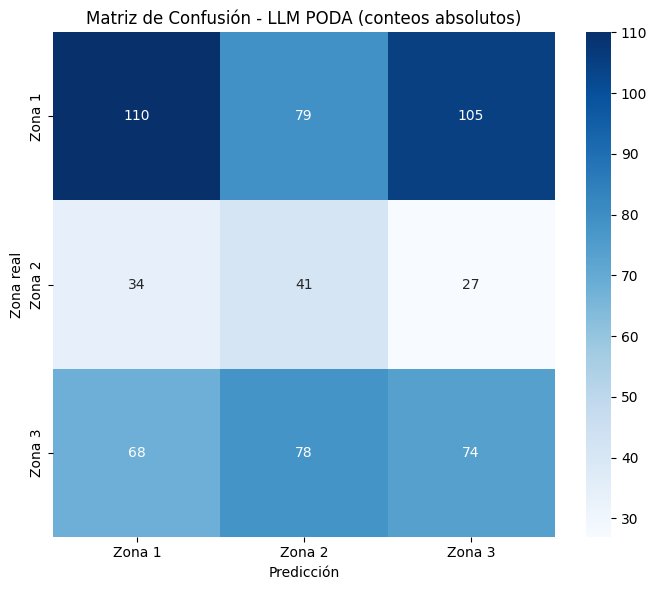

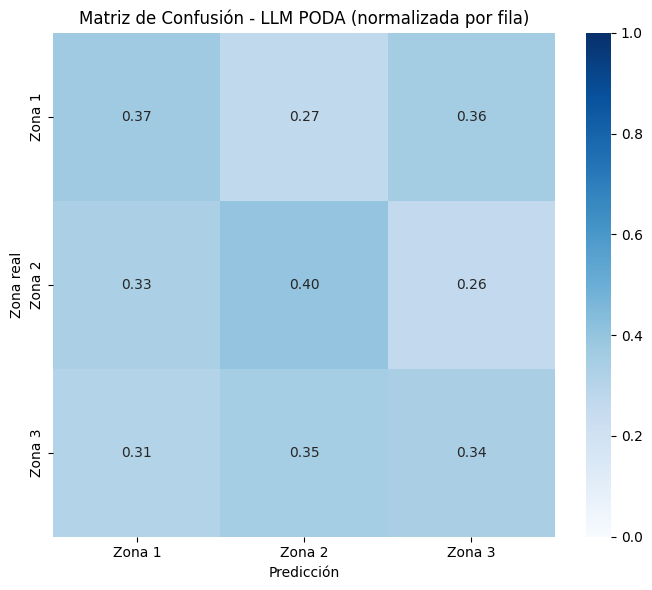

In [5]:
evaluador = EvaluadorResultados()
evaluador.evaluar("predicciones_finales_tras_poda.csv", "PODA")

# Iteración 5: Revisión Macro-Gestual con Qwen-3.5-VL y Evaluación del Módulo Textual

La conclusión metodológica extraída de la iteración anterior fue contundente: el retorno a un enfoque micro-biomecánico (centrado en detalles milimétricos como la flexión articular) no bastaba, por sí solo, para resolver las limitaciones predictivas del sistema. Ante esta evidencia, la quinta iteración plantea un retorno estratégico al planteamiento macro-gestual explorado originalmente en la Iteración 2, el cual había demostrado un comportamiento conceptualmente más prometedor. El objetivo no es forzar un mayor nivel de detalle anatómico en la memoria visual, sino comprobar si una formulación basada en las señales globales del movimiento puede beneficiarse del salto cualitativo que ofrecen los modelos multimodales más recientes.

Para aislar y evaluar esta hipótesis, la arquitectura general del sistema se mantiene estrictamente modular. En el frente de extracción visual, se establece como constante el uso de **Qwen-3.5-VL 8B**. A diferencia de la Iteración 4, el motor de visión ya no persigue medir el ángulo exacto de un tobillo o la superficie de impacto aislada; su labor es capturar la "huella global" del gesto: la orientación general del torso, la inercia de la carrera, la apertura de la cadera y la dirección aparente del seguimiento de la pierna de golpeo. Toda esta evidencia se sintetiza en una memoria textual descriptiva.

El segundo eje de esta iteración se centra en el motor de inferencia. Una vez generada la memoria visual macro-gestual, un Modelo de Lenguaje (LLM) asume la tarea de leerla y deducir la intención táctica del jugador, devolviendo una etiqueta relativa a la biomecánica pura (`CRUZADO`, `CENTRAL` o `ABIERTO`). Esta predicción anatómica se mapea posteriormente a las zonas numéricas de la portería (1, 2, 3), manteniendo intacta la separación entre el razonamiento relativo al cuerpo y la evaluación espacial absoluta. 

Para someter a prueba esta configuración, el diseño experimental se ramificó en cuatro familias de *prompts* y dos familias de modelos de inferencia:

* **Reevaluación de los Prompts Históricos:** Se recuperaron los *prompts* de la Iteración 2 (el *Prompt Cerrado*, el *Prompt Abierto 1* y el *Prompt Abierto 2*) para inyectarlos en el nuevo VLM. Esto permitió medir empíricamente si la red neuronal de visión actualizada era capaz de extraer información direccional más nítida utilizando las mismas directrices que fallaron en el pasado.
* **El Prompt Abierto Final:** Basado en las carencias detectadas en las primeras pruebas de esta fase, se diseñó una formulación de *prompt* de síntesis, orientada específicamente a forzar al modelo visual a priorizar aquellas macro-señales que guardan una correlación directa e indiscutible con la trayectoria del balón.
* **Auditoría del Razonamiento Textual:** Para evitar que un sesgo lingüístico se confundiera con un fallo de visión, el *Prompt Abierto 2* se evaluó en paralelo utilizando dos LLMs distintos: **Qwen 3.5 9B** y **Llama**. Esta comparativa fue vital para determinar si una predicción incorrecta nace de una alucinación visual del VLM o de un fallo de lectura y comprensión por parte del modelo de lenguaje.

Desde una perspectiva de investigación, esta iteración no busca reinventar la rueda, sino agotar la vía macro-gestual con la mejor tecnología disponible de forma local. Si las limitaciones predictivas —especialmente la alta entropía generada por los lanzamientos por el centro— persisten tras esta actualización de modelos y *prompts*, se confirmará de manera definitiva que el cuello de botella del proyecto no reside en la red neuronal utilizada, sino en la propia naturaleza ambigua e incompleta de las señales visuales disponibles en una transmisión televisiva estándar.

### 1. Configuración Base y Procesamiento Visual

Para garantizar el rigor experimental de esta quinta iteración y aislar de forma efectiva el impacto de las nuevas configuraciones de *prompting* y el cambio en el motor de inferencia textual, se mantuvo estrictamente inalterado el núcleo de preprocesamiento visual algorítmico. 

Al igual que en las fases de control anteriores, este bloque fundacional gestiona la lectura de los datos de seguimiento, la extracción dinámica de los recortes del jugador mediante las cajas delimitadoras originales y la estandarización geométrica de los tensores visuales. La segmentación cronológica del movimiento —que divide la acción en carrera inicial, plantada, impacto y seguimiento en torno al fotograma clave del golpeo— continúa operando como el formato estándar de entrada. De este modo, se asegura que el modelo de visión Qwen-3.5-VL reciba exactamente el mismo sustrato espaciotemporal que en las iteraciones previas, permitiendo que cualquier variación en el rendimiento final sea atribuible en exclusiva a la arquitectura de los modelos o a la reformulación lingüística de las instrucciones.

In [ ]:
import cv2
import base64
import os
import time
import pandas as pd
from openai import OpenAI
import matplotlib.pyplot as plt
import numpy as np

# CONFIGURACIÓN
# 8192
CLIENT = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")

BASE_DIR = r'C:\Users\david\OneDrive\Desktop\TFT_LLMPenalties2026'
CSV_ORIGINAL_PATH = os.path.join(BASE_DIR, 'labeled_frames_cuttedvids.csv')
CSV_GROUPED_PATH = os.path.join(BASE_DIR, 'labeled_frames_grouped.csv')
VIDEOS_DIR = os.path.join(BASE_DIR, 'modified_videos')
RESULTADOS_MEMORIA_PATH = os.path.join(BASE_DIR, 'memorias_visuales.csv')
DF_ORIGINAL = pd.read_csv(CSV_ORIGINAL_PATH)

def resize_keep_aspect_ratio(image, target_size=384):
    """ Escala una imagen sin deformarla y añade franjas negras """
    old_h, old_w = image.shape[:2]
    ratio = min(target_size / old_w, target_size / old_h)
    new_w = int(old_w * ratio)
    new_h = int(old_h * ratio)
    
    if ratio < 1.0:
        interp = cv2.INTER_AREA
    else:
        interp = cv2.INTER_CUBIC
        
    resized = cv2.resize(image, (new_w, new_h), interpolation=interp)
    
    delta_w = target_size - new_w
    delta_h = target_size - new_h
    top, bottom = delta_h // 2, delta_h - (delta_h // 2)
    left, right = delta_w // 2, delta_w - (delta_w // 2)
    
    padded_img = cv2.copyMakeBorder(resized, top, bottom, left, right, 
                                    cv2.BORDER_CONSTANT, value=[0, 0, 0])
    return padded_img

def encode_image_to_base64(frame):
    _, buffer = cv2.imencode('.jpg', frame, [int(cv2.IMWRITE_JPEG_QUALITY), 95])
    return base64.b64encode(buffer).decode('utf-8')

def get_correct_bbox(vid_data, frame_idx_modificado, target_frames=64):
    total_original_frames = len(vid_data)
    if total_original_frames == 0: return None
    if total_original_frames > target_frames:
        indice_real = frame_idx_modificado + (total_original_frames - target_frames)
    elif total_original_frames < target_frames:
        padding_size = target_frames - total_original_frames
        indice_real = 0 if frame_idx_modificado < padding_size else frame_idx_modificado - padding_size
    else:
        indice_real = frame_idx_modificado
    indice_real = min(indice_real, len(vid_data) - 1)
    return int(vid_data.iloc[indice_real]['BB_x']), int(vid_data.iloc[indice_real]['BB_y']), int(vid_data.iloc[indice_real]['BB_w']), int(vid_data.iloc[indice_real]['BB_h'])

def get_kick_frame_idx(vid_data, target_frames=64):
    total_orig = len(vid_data)
    kick_rows = vid_data[vid_data['kick_frame'] == 1]
    kick_orig = int(kick_rows.iloc[0]['frame_id']) if len(kick_rows) > 0 else total_orig // 2

    if total_orig > target_frames:
        kick_mod = kick_orig - (total_orig - target_frames)
    elif total_orig < target_frames:
        kick_mod = kick_orig + (target_frames - total_orig)
    else:
        kick_mod = kick_orig

    total_mod = min(total_orig, target_frames)
    return max(0, min(total_mod - 1, kick_mod))

def crop_frame(frame, vid_data, frame_idx, target_frames=64, pad=100):
    """ Recorta el jugador usando el Bounding Box y añade un margen de padding dinámico """
    bbox = get_correct_bbox(vid_data, frame_idx, target_frames=target_frames)
    if bbox:
        x, y, w, h = bbox
        H, W, _ = frame.shape
        x1, y1 = max(0, x - pad), max(0, y - pad)
        x2, y2 = min(W, x + w + pad), min(H, y + h + pad)
        return resize_keep_aspect_ratio(frame[y1:y2, x1:x2], target_size=384)
    return resize_keep_aspect_ratio(frame, target_size=512)

def sample_frames_from_range(frames, vid_data, start, end, n_samples):
    segment = list(range(start, end))
    if not segment: return []
    if len(segment) <= n_samples:
        indices = segment
    else:
        indices = [segment[int(i * len(segment) / n_samples)] for i in range(n_samples)]
    return [encode_image_to_base64(crop_frame(frames[i], vid_data, i)) for i in indices]

def extract_frames_by_phase(video_path, vid_data, n_carrera_1=4, n_carrera_2=6, n_impacto=3, n_seguimiento=6):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret: break
        frames.append(frame)
    cap.release()
    if not frames: return None

    kick_idx = get_kick_frame_idx(vid_data)
    total = len(frames)
    
    fase_carrera_1   = (0, max(1, kick_idx - 12))
    
    fase_carrera_2   = (max(1, kick_idx - 12), max(2, kick_idx - 1))
    
    fase_impacto     = (max(0, kick_idx - 1), min(total, kick_idx + 2))
    
    fase_seguimiento = (min(total, kick_idx + 2), total)

    return {
        "carrera_1":     sample_frames_from_range(frames, vid_data, *fase_carrera_1,   n_carrera_1),
        "carrera_2":     sample_frames_from_range(frames, vid_data, *fase_carrera_2,   n_carrera_2),
        "impacto":       sample_frames_from_range(frames, vid_data, *fase_impacto,     n_impacto),
        "seguimiento":   sample_frames_from_range(frames, vid_data, *fase_seguimiento, n_seguimiento),
        "kick_idx":      kick_idx,
        "total":         total,
        "n_carrera_1":   n_carrera_1,
        "n_carrera_2":   n_carrera_2,
        "n_impacto":     n_impacto,
        "n_seguimiento": n_seguimiento,
    }

### 3. Generación de la Memoria Visual: Enfoque Macro-Gestual (Variante Cerrada)

Para ejecutar la primera de las configuraciones experimentales planteadas en esta quinta iteración, se implementó este bloque de código que recupera íntegramente el *prompt* cerrado de base macro-gestual diseñado durante la Iteración 2. El objetivo central es evaluar si la arquitectura multimodal actualizada (Qwen-3.5-VL 8B) logra una mayor consistencia y precisión al clasificar el movimiento global del lanzador bajo un sistema de opciones discretas fuertemente restringido.

En contraste con las iteraciones focalizadas en la micro-biomecánica, esta variante no exige al modelo medir ángulos exactos ni posiciones relativas milimétricas. En su lugar, el *prompt* instruye a la red neuronal para que observe el bloque corporal en su conjunto y asigne etiquetas predefinidas a las dinámicas globales de cada fase: la diagonalidad de la aproximación, la orientación del pecho en la plantada, la superficie aparente de impacto y la inercia general del tronco durante el seguimiento. Para mitigar las alucinaciones derivadas de la obturación de la cámara y el *motion blur* —factores críticos detectados en fases anteriores—, se mantuvieron ancladas en las instrucciones del sistema las "reglas biomecánicas estrictas", las cuales prohíben físicamente conclusiones imposibles (como una rodilla apuntando hacia arriba en el instante de impacto o una pierna de seguimiento descendente).

Finalmente, para garantizar la inmutabilidad estructural de la memoria generada, el módulo incorpora una función de limpieza y ensamblaje apoyada en expresiones regulares (`re.search`). Este submódulo extrae exclusivamente la etiqueta seleccionada por el modelo dentro de los corchetes requeridos, descartando cualquier razonamiento previo (fase de *ANÁLISIS VISUAL*) y construyendo un bloque de texto altamente sintético y libre de ruido lingüístico de cara a la etapa de inferencia textual posterior.

In [2]:
import re

def construir_memoria_estructurada(desc_carrera_1, desc_carrera_2, desc_impacto, desc_seguimiento):
    def extraer(texto, etiqueta_regex):
        if not texto: return "no se apreció"
        match = re.search(rf"\[?{etiqueta_regex}\]?.*?:?\s*(.*)", texto, re.IGNORECASE)
        if match:
            return match.group(1).replace('*', '').strip().split('\n')[0]
        return "no se apreció"

    aproximacion = extraer(desc_carrera_1, "ANGULO") 
    apoyo        = extraer(desc_carrera_2, "PIE_APOYO")
    pecho        = extraer(desc_carrera_2, "PECHO")
    rodilla      = extraer(desc_impacto,   "RODILLA")
    pie_impacto  = extraer(desc_impacto,   "PIE_IMPACTO")
    trayectoria  = extraer(desc_seguimiento, "TRAYECTORIA") 
    inercia      = extraer(desc_seguimiento, "INERCIA")

    return (
        f"CARRERA: {aproximacion}\n"
        f"APOYO: Pie apunta a {apoyo} / Pecho mira a {pecho}\n"
        f"IMPACTO: Rodilla apunta a {rodilla} / Superficie visible: {pie_impacto}\n"
        f"SEGUIMIENTO: {trayectoria} / Inercia tronco: {inercia}"
    )

def generar_memoria_visual(video_path, vid_data, pierna):
    fases = extract_frames_by_phase(video_path, vid_data) 
    if not fases: return None

    def llamar_vlm(frames_b64, prompt_sistema, prompt_usuario):
        if not frames_b64: return "No hay frames."
        content = [{"type": "text", "text": prompt_usuario}]
        for img in frames_b64:
            content.append({"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{img}"}})
        try:
            response = CLIENT.chat.completions.create(
                model="local-model", 
                messages=[
                    {"role": "system", "content": prompt_sistema},
                    {"role": "user",   "content": content}
                ],
                max_tokens=400,
                temperature=0.1 
            )
            return response.choices[0].message.content
        except Exception as e:
            return f"Error: {e}"

    prompt_sistema_fase = f"""Eres un analista biomecánico de visión artificial experto en fútbol.
DATO FIJO: El jugador patea con la pierna {pierna.upper()}.
CÁMARA: Situada en DIAGONAL y a la DERECHA del jugador.

REGLAS BIOMECÁNICAS ESTRICTAS (OBLIGATORIAS):
1. ANATOMÍA DEL IMPACTO: En el momento del golpeo, la rodilla de la pierna activa apunta hacia adelante o hacia abajo, NUNCA hacia arriba.
2. FÍSICA DEL SEGUIMIENTO: Tras el impacto, la pierna de golpeo SIEMPRE sigue una trayectoria ascendente (hacia arriba) por inercia, NUNCA descendente. El torso gira en sentido contrario a la pierna para compensar.
3. TOLERANCIA AL DESENFOQUE: Las extremidades en movimiento tendrán 'motion blur'. Infiere la posición usando la cadena cinética (cadera, torso, postura general). Usa 'BORROSO' SOLO si la imagen está totalmente obstruida.

ESTRUCTURA OBLIGATORIA:
ANÁLISIS VISUAL: (Razonamiento de 1-2 líneas justificando la postura anatómica)
[ETIQUETA]: (Conclusión estricta de máximo 5 palabras)"""

    desc_carrera_1 = llamar_vlm(
        fases["carrera_1"], prompt_sistema_fase,
        f"""FASE DE CARRERA INICIAL. 
Evalúa el ángulo de aproximación del jugador hacia el balón.
Elige UNA de estas opciones para la etiqueta: [Frontal, Diagonal, Lateral].
Responde estrictamente:
[ANGULO]: (Tu elección)"""
    )

    desc_carrera_2 = llamar_vlm(
        fases["carrera_2"], prompt_sistema_fase,
        f"""FASE DE CARRERA FINAL (Plantada).
Evalúa hacia dónde apunta la PUNTA del pie de apoyo.
Elige UNA opción:
Pie: [Apunta recto al frente, Apunta hacia afuera (abierto), Apunta hacia adentro (cerrado)]
Pecho: [Frontal al balón, Ladeado]
Responde estrictamente:
[PIE_APOYO]: (Tu elección)
[PECHO]: (Tu elección)"""
    )

    desc_impacto = llamar_vlm(
        fases["impacto"], prompt_sistema_fase,
        f"""FASE DE IMPACTO. Pierna: {pierna.upper()}.
Recuerda la Regla 1: La rodilla no puede apuntar arriba.
Elige UNA opción para cada etiqueta:
Rodilla: [Adelante, Abajo/Balón]
Superficie: [Empeine total, Empeine interior, Interior, Puntera]
Responde estrictamente:
[RODILLA]: (Tu elección)
[PIE_IMPACTO]: (Tu elección)"""
    )

    desc_seguimiento = llamar_vlm(
    fases["seguimiento"], prompt_sistema_fase,
    f"""FASE DE SEGUIMIENTO. Pierna que patea: {pierna.upper()}.
OJO: La cámara está en DIAGONAL. No confundas la perspectiva con el giro real del jugador.
Fíjate EXCLUSIVAMENTE en los HOMBROS y la CADERA tras el impacto.
Elige UNA opción estricta para cada etiqueta:
Trayectoria pierna: [Cruza el eje del cuerpo, Sigue recta hacia adelante, Se abre hacia la derecha]
Inercia tronco: [Hombros giran bruscamente a la izquierda, Hombros se quedan mirando al frente, Hombros caen hacia atrás/derecha]
Responde estrictamente:
[TRAYECTORIA]: (Tu elección)
[INERCIA]: (Tu elección)"""
)

    return {
        "final": construir_memoria_estructurada(desc_carrera_1, desc_carrera_2, desc_impacto, desc_seguimiento),
        "raw_1": desc_carrera_1,
        "raw_2": desc_carrera_2,
        "raw_3": desc_impacto,
        "raw_4": desc_seguimiento
    }

### 4. Generación de la Memoria Visual: Enfoque Macro-Gestual (Variante Abierta 1)

Continuando con el despliegue de las configuraciones de la quinta iteración, se implementó este bloque correspondiente a la primera formulación abierta (recuperada de la Iteración 2). A diferencia del enfoque cerrado anterior, que forzaba al modelo a elegir entre etiquetas rígidas predefinidas, esta variante otorga a Qwen-3.5-VL 8B la libertad de redactar descripciones analíticas en texto libre. Sin embargo, la atención se mantiene anclada firmemente en el paradigma macro-gestual: en lugar de exigir la medición de ángulos articulares precisos, se solicita la evaluación de dinámicas globales altamente predictivas, como la extensión del brazo de equilibrio, la inclinación del bloque superior, el latigazo inercial del seguimiento (*frenado vs cruce*) y la rotación general de la cadera.

Una característica metodológica distintiva de este bloque es la contundencia de las instrucciones base (*system prompt*). Para mitigar el problema de los falsos negativos visuales y evitar que el modelo evada el análisis ante resoluciones bajas, desenfoques por movimiento (*motion blur*) u oclusiones parciales, se introdujo una directiva absoluta de "anti-evasión": el modelo tiene expresamente prohibido responder que un elemento "no es visible". Esta coerción algorítmica fuerza a la red neuronal a apoyarse en la cadena cinética del jugador para emitir la estimación geométrica más probable a partir de los píxeles disponibles. El propósito empírico de esta ejecución es determinar si un motor de visión actualizado puede aprovechar esta libertad descriptiva sin incurrir en alucinaciones biomecánicas o suposiciones teóricas.

In [3]:
import pandas as pd

def construir_memoria_estructurada(desc_carrera_1, desc_carrera_2, desc_impacto, desc_seguimiento):
    def limpiar(texto):
        return texto.strip() if texto else "No se pudo extraer información."

    return (
        f"--- FASE DE CARRERA INICIAL ---\n{limpiar(desc_carrera_1)}\n\n"
        f"--- FASE DE PLANTA/APOYO ---\n{limpiar(desc_carrera_2)}\n\n"
        f"--- FASE DE IMPACTO ---\n{limpiar(desc_impacto)}\n\n"
        f"--- FASE DE SEGUIMIENTO E INERCIA ---\n{limpiar(desc_seguimiento)}"
    )

def generar_memoria_visual(video_path, vid_data, pierna):
    fases = extract_frames_by_phase(video_path, vid_data) 
    if not fases: return None

    def llamar_vlm(frames_b64, prompt_sistema, prompt_usuario):
        if not frames_b64: return "No hay frames."
        content = [{"type": "text", "text": prompt_usuario}]
        for img in frames_b64:
            content.append({"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{img}"}})
        try:
            response = CLIENT.chat.completions.create(
                model="local-model", 
                messages=[{"role": "system", "content": prompt_sistema},
                          {"role": "user",   "content": content}],
                max_tokens=800,
                temperature=0.3 
            )
            return response.choices[0].message.content
        except Exception as e:
            return f"Error visual: {e}"

    prompt_sistema_fase = f"""Eres un analista biomecánico de visión artificial.
Analizas a un jugador pateando un penalti con la pierna {pierna.upper()}, 
visto desde una cámara diagonal trasera.

REGLA ABSOLUTA: SIEMPRE debes describir lo que ves. 
Nunca respondas "no es visible" ni "no se puede determinar".
Si hay incertidumbre, describe lo que más probablemente ves y añade "(estimación)".
Las imágenes siempre contienen información útil. Úsala.
PROHIBIDO usar biomecánica teórica para deducir respuestas.
Cada afirmación debe basarse en píxeles concretos que puedas señalar.
Si usas la palabra 'típico' o 'consistente con', te estás equivocando. Describe SOLO lo que ves, no lo que sabes."""


    desc_carrera_1 = llamar_vlm(
        fases["carrera_1"], prompt_sistema_fase,
        f"""Compara el inicio y el final de esta secuencia de aproximación al balón y describe los siguientes aspectos:
        
1. Ángulo de Aproximación (APA): Identifica en qué lado del balón inicia la carrera el jugador (izquierda o derecha visualmente). A partir de ahí, describe la trayectoria espacial de su centro de masa para llegar al balón. ¿Es una aproximación frontal, o una diagonal cruzada hacia la derecha/izquierda?
2. Patrón de Marcha y Postura: Describe la inclinación del torso respecto a la cadera durante la carrera. ¿El jugador mantiene una postura erguida o su centro de gravedad desciende a medida que se acerca al balón?
3. Dinámica del movimiento: Describe la amplitud de la zancada y cómo el jugador balancea los brazos para generar momento angular."""
    )

    pie_apoyo = "izquierdo" if pierna.lower() == "derecha" else "derecho"

    desc_carrera_2 = llamar_vlm(
        fases["carrera_2"], prompt_sistema_fase,
        f"""Observa la secuencia de la fase de planta y describe en texto libre:

1. Ángulo de llegada: Confirma desde qué dirección (izquierda o derecha del balón) se ha aproximado el jugador para realizar la plantada.

2. Postura del torso: Describe la inclinación del torso. ¿El jugador mantiene el tronco erguido o se inclina hacia adelante, adelantando los hombros sobre el eje del balón?

3. Orientación del pie de apoyo ({pie_apoyo.upper()}): Teniendo en cuenta que la cámara graba desde una diagonal trasera, evalúa la dirección biomecánica real del pie en el campo. ¿La punta está orientada hacia la zona de la portería (al frente/ligeramente cruzado) o apunta de forma antinatural hacia el exterior? 

4. Ubicación respecto al balón: En el eje de avance, ¿el pie de apoyo se planta retrasado, alineado a la misma altura, o adelantado respecto a la línea imaginaria que cruza el centro del balón?"""
    )

    brazo_equilibrio = "izquierdo" if pierna.lower() == "derecha" else "derecho"
    
    desc_impacto = llamar_vlm(
    fases["impacto"], prompt_sistema_fase,
    f"""Observa el frame exacto del contacto pie-balón y responde SOLO a esto:

1. El Brazo de Equilibrio (CRÍTICO): Fíjate en el brazo {brazo_equilibrio.upper()} del jugador. ¿Está recogido/flexionado cerca del cuerpo, o está completamente extendido y levantado hacia afuera (como un ala) alejándose del torso?

2. Inclinación de la Espalda: ¿La espalda está curvada hacia adelante (encorvada sobre el balón) o el jugador echa el tronco ligeramente hacia atrás/hacia el lado de apoyo?

3. Orientación de la Cadera: Ignora la bota. Fíjate en la cadera de la pierna de golpeo ({pierna.upper()}). ¿Está rotada agresivamente hacia adelante buscando la portería, o se nota que la cadera se ha "abierto" hacia el exterior?"""
)

    desc_seguimiento = llamar_vlm(
        fases["seguimiento"], prompt_sistema_fase,
        f"""Mira SOLO la fase de seguimiento (después del impacto).

1. La Rodilla de Golpeo (CRÍTICO): Fíjate en la rodilla de la pierna {pierna.upper()}. Tras golpear, ¿la rodilla apunta hacia el frente (o hacia adentro, cruzando el cuerpo), o la rodilla se queda apuntando hacia AFUERA (hacia el lateral del campo) revelando que la cadera se quedó abierta?

2. Frenado vs Cruce: ¿La pierna de golpeo frena su recorrido rápidamente tras el impacto, o da un latigazo cruzando violentamente por delante de la pierna de apoyo?

3. Altura del pie: ¿El pie de golpeo sube por encima de la cadera o se queda cerca del césped?"""
    )

    return {
        "final": construir_memoria_estructurada(desc_carrera_1, desc_carrera_2, desc_impacto, desc_seguimiento)
    }

### 5. Generación de la Memoria Visual: Enfoque Macro-Gestual (Variante Abierta 2)

Avanzando en la batería de pruebas de esta quinta iteración, se implementó el bloque correspondiente a la segunda formulación abierta. Esta variante reviste especial importancia, ya que durante la Iteración 2 demostró ser el enfoque más prometedor para capturar la esencia direccional del disparo. Al igual que en la variante anterior, se conservó intacto el contundente *prompt* de sistema —que prohíbe la evasión visual y obliga al modelo a realizar estimaciones probabilísticas basadas en la cadena cinética—, así como las instrucciones de análisis para las fases de carrera y plantada.

La diferencia metodológica fundamental de esta segunda variante radica en la reestructuración de las preguntas dirigidas a los instantes críticos del impacto y el seguimiento. En lugar de interrogar a la red neuronal sobre conceptos biomecánicos complejos o dinámicas abstractas (como el comportamiento del brazo de equilibrio o el latigazo cruzado de la pierna), el *prompt* pivotó hacia un literalismo espacial estricto. En la fase de impacto, se priorizó la orientación global del torso y el estado de flexión/extensión de las articulaciones. En la fase de seguimiento, la evaluación se redujo a coordenadas puramente bidimensionales, obligando al VLM a responder binariamente si el pie y el cuerpo se desplazan hacia la "DERECHA" o hacia la "IZQUIERDA" del encuadre de la imagen.

El objetivo subyacente de esta formulación es aligerar la carga cognitiva del modelo de visión. Al despojar las instrucciones de jerga biomecánica y solicitar observaciones espaciales directas y literales, se pretende minimizar el riesgo de que Qwen-3.5-VL 8B alucine justificaciones teóricas que no están presentes en los píxeles. Esta variante evalúa empíricamente si un modelo multimodal avanzado alcanza su máxima precisión predictiva cuando actúa como un descriptor geométrico puro, delegando toda la deducción táctica compleja al modelo de lenguaje en la etapa posterior.

In [7]:
import pandas as pd

def construir_memoria_estructurada(desc_carrera_1, desc_carrera_2, desc_impacto, desc_seguimiento):
    def limpiar(texto):
        return texto.strip() if texto else "No se pudo extraer información."

    return (
        f"--- FASE DE CARRERA INICIAL ---\n{limpiar(desc_carrera_1)}\n\n"
        f"--- FASE DE PLANTA/APOYO ---\n{limpiar(desc_carrera_2)}\n\n"
        f"--- FASE DE IMPACTO ---\n{limpiar(desc_impacto)}\n\n"
        f"--- FASE DE SEGUIMIENTO E INERCIA ---\n{limpiar(desc_seguimiento)}"
    )

def generar_memoria_visual(video_path, vid_data, pierna):
    fases = extract_frames_by_phase(video_path, vid_data) 
    if not fases: return None

    def llamar_vlm(frames_b64, prompt_sistema, prompt_usuario):
        if not frames_b64: return "No hay frames."
        content = [{"type": "text", "text": prompt_usuario}]
        for img in frames_b64:
            content.append({"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{img}"}})
        try:
            response = CLIENT.chat.completions.create(
                model="local-model", 
                messages=[{"role": "system", "content": prompt_sistema},
                          {"role": "user",   "content": content}],
                max_tokens=800,
                temperature=0.3 
            )
            return response.choices[0].message.content
        except Exception as e:
            return f"Error visual: {e}"

    prompt_sistema_fase = f"""Eres un analista biomecánico de visión artificial.
Analizas a un jugador pateando un penalti con la pierna {pierna.upper()}, 
visto desde una cámara diagonal trasera.

REGLA ABSOLUTA: SIEMPRE debes describir lo que ves. 
Nunca respondas "no es visible" ni "no se puede determinar".
Si hay incertidumbre, describe lo que más probablemente ves y añade "(estimación)".
Las imágenes siempre contienen información útil. Úsala.
PROHIBIDO usar biomecánica teórica para deducir respuestas.
Cada afirmación debe basarse en píxeles concretos que puedas señalar.
Si usas la palabra 'típico' o 'consistente con', te estás equivocando. Describe SOLO lo que ves, no lo que sabes."""

    desc_carrera_1 = llamar_vlm(
        fases["carrera_1"], prompt_sistema_fase,
        f"""Compara el inicio y el final de esta secuencia de aproximación al balón y describe los siguientes aspectos:
        
1. Ángulo de Aproximación (APA): Identifica en qué lado del balón inicia la carrera el jugador (izquierda o derecha visualmente). A partir de ahí, describe la trayectoria espacial de su centro de masa para llegar al balón. ¿Es una aproximación frontal, o una diagonal cruzada hacia la derecha/izquierda?
2. Patrón de Marcha y Postura: Describe la inclinación del torso respecto a la cadera durante la carrera. ¿El jugador mantiene una postura erguida o su centro de gravedad desciende a medida que se acerca al balón?
3. Dinámica del movimiento: Describe la amplitud de la zancada y cómo el jugador balancea los brazos para generar momento angular."""
    )

    pie_apoyo = "izquierdo" if pierna.lower() == "derecha" else "derecho"

    desc_carrera_2 = llamar_vlm(
        fases["carrera_2"], prompt_sistema_fase,
        f"""Observa la secuencia de la fase de planta y describe en texto libre:

1. Ángulo de llegada: Confirma desde qué dirección (izquierda o derecha del balón) se ha aproximado el jugador para realizar la plantada.

2. Postura del torso: Describe la inclinación del torso. ¿El jugador mantiene el tronco erguido o se inclina hacia adelante, adelantando los hombros sobre el eje del balón?

3. Orientación del pie de apoyo ({('izquierdo' if pierna.lower() == 'derecha' else 'derecho').upper()}): Teniendo en cuenta que la cámara graba desde una diagonal trasera, evalúa la dirección biomecánica real del pie en el campo. ¿La punta está orientada hacia la zona de la portería (al frente/ligeramente cruzado) o apunta de forma antinatural hacia el exterior? 

4. Ubicación respecto al balón: En el eje de avance, ¿el pie de apoyo se planta retrasado, alineado a la misma altura, o adelantado respecto a la línea imaginaria que cruza el centro del balón?"""
    )

    desc_impacto = llamar_vlm(
    fases["impacto"], prompt_sistema_fase,
    f"""Observa el frame del contacto pie-balón y describe:

1. Orientación del torso: ¿Hacia dónde apunta el pecho del jugador en el momento exacto del contacto? Ten en cuenta si está en pleno giro dinámico intentando cuadrarse hacia la portería o si ya ha rotado hacia algún lateral.

2. Punto de contacto: ¿Qué parte de la bota contacta el balón? Describe la zona visible (ej. empeine, puntera, interior) aunque sea aproximado debido a la resolución.

3. Estado articular: Describe el grado de extensión de la pierna de golpeo (considerando que en biomecánica deportiva suele haber una ligerísima flexión para no bloquear la articulación en el impacto). ¿Cuál es el grado de flexión de la pierna de apoyo?"""
)

    desc_seguimiento = llamar_vlm(
        fases["seguimiento"], prompt_sistema_fase,
        f"""Mira SOLO la fase de seguimiento (después del impacto).
Describe ÚNICAMENTE lo que ves en los píxeles:

1. Tras el impacto, el pie {pierna.upper()} ¿se mueve hacia la DERECHA de la imagen 
   o hacia la IZQUIERDA de la imagen? Elige una de las dos opciones.
   Describe brevemente qué píxeles te llevan a esa conclusión.

2. ¿El pie sube por encima de la cadera o se queda por debajo?

3. El cuerpo del jugador, ¿gira hacia la derecha de la imagen o hacia la izquierda?"""
    )

    return {
        "final": construir_memoria_estructurada(desc_carrera_1, desc_carrera_2, desc_impacto, desc_seguimiento)
    }

### 6. Ejecución del VLM y Generación de Memorias Visuales

Para orquestar la ejecución masiva del modelo multimodal Qwen-3.5-VL 8B y automatizar la extracción de las memorias visuales macro-gestuales, se reutilizó de forma íntegra el motor de procesamiento en lote consolidado a lo largo del proyecto. Al mantener este bloque de código inalterado, se asegura que el flujo de lectura de los recortes de vídeo, la invocación a la API local y la persistencia de los datos operen de manera idéntica a las iteraciones anteriores. 

El *script* está diseñado para garantizar la robustez del experimento frente a posibles interrupciones del servidor local o cuellos de botella en la memoria del sistema. Para ello, realiza una comprobación previa en el archivo `memorias_visuales.csv`, identificando los identificadores de vídeo (`vid_ID`) ya procesados y filtrando la cola de ejecución para procesar exclusivamente los casos pendientes (en lotes manejables, como los 200 vídeos configurados en esta celda). Cada memoria generada se anexa dinámicamente al archivo de resultados, asegurando una trazabilidad completa y protegiendo el progreso continuo de la extracción visual de cara a la fase de inferencia táctica.

In [3]:
df_agrupado = pd.read_csv(CSV_GROUPED_PATH)
procesados_memoria = set()

if os.path.exists(RESULTADOS_MEMORIA_PATH):
    df_existente = pd.read_csv(RESULTADOS_MEMORIA_PATH)
    if 'vid_ID' in df_existente.columns:
        procesados_memoria = set(df_existente['vid_ID'])

videos_pendientes = [v for v in df_agrupado['vid_ID'].unique() if v not in procesados_memoria][:200]

print(f"Videos pendientes por procesar en este lote: {len(videos_pendientes)}")

for vid_id in videos_pendientes:
    print(f"--- Procesando Vídeo: {vid_id} ---")

    fila_video = df_agrupado[df_agrupado['vid_ID'] == vid_id].iloc[0]
    vid_data_original = DF_ORIGINAL[DF_ORIGINAL['vid_ID'] == vid_id].sort_values(by='frame_id').reset_index(drop=True)
    video_path = os.path.join(VIDEOS_DIR, f"{vid_id}.mp4")

    pierna = "derecha" if fila_video['kicker_foot'] == 0 else "izquierda"
    memoria_dict = generar_memoria_visual(video_path, vid_data_original, pierna)

    if memoria_dict:

        nuevo_registro = pd.DataFrame([{
            'vid_ID': vid_id, 
            'kicker_foot': pierna, 
            'memoria_generada': memoria_dict['final']
        }])

        nuevo_registro.to_csv(
            RESULTADOS_MEMORIA_PATH, 
            mode='a', 
            header=not os.path.exists(RESULTADOS_MEMORIA_PATH), 
            index=False
        )
        print(f"Memoria descriptiva de {vid_id} guardada con éxito.\n")

        time.sleep(1)
    else:
        print(f"Error procesando el vídeo {vid_id}, se saltará.\n")

Videos pendientes por procesar en este lote: 200
--- Procesando Vídeo: v53_p8_diag ---
Memoria descriptiva de v53_p8_diag guardada con éxito.

--- Procesando Vídeo: v53_p9_diag ---
Memoria descriptiva de v53_p9_diag guardada con éxito.

--- Procesando Vídeo: v53_p10_diag ---
Memoria descriptiva de v53_p10_diag guardada con éxito.

--- Procesando Vídeo: v53_p11_diag ---
Memoria descriptiva de v53_p11_diag guardada con éxito.

--- Procesando Vídeo: v54_p1_diag ---
Memoria descriptiva de v54_p1_diag guardada con éxito.

--- Procesando Vídeo: v54_p2_diag ---
Memoria descriptiva de v54_p2_diag guardada con éxito.

--- Procesando Vídeo: v54_p3_diag ---
Memoria descriptiva de v54_p3_diag guardada con éxito.

--- Procesando Vídeo: v54_p4_diag ---
Memoria descriptiva de v54_p4_diag guardada con éxito.

--- Procesando Vídeo: v54_p5_diag ---
Memoria descriptiva de v54_p5_diag guardada con éxito.

--- Procesando Vídeo: v54_p6_diag ---
Memoria descriptiva de v54_p6_diag guardada con éxito.

--- Pro

### 7. Inferencia Final mediante LLM: Evaluación de la Memoria Cerrada

Prosiguiendo con el diseño experimental de la quinta iteración, se implementó el módulo de inferencia textual encargado de procesar la memoria visual cerrada. Para garantizar una trazabilidad perfecta en la comparativa, este bloque recupera exactamente el mismo *prompt* de evaluación macro-gestual utilizado durante la Iteración 2. El objetivo es analizar cómo los nuevos modelos de lenguaje (principalmente Qwen3.5-9B, y de forma comparativa, Llama) interpretan y ponderan un conjunto de etiquetas rígidas predefinidas que describen la acción global del lanzador.

Las instrucciones del sistema mantienen inalterada la lógica de resolución biomecánica: establecen las reglas espaciales de lateralidad en función de la pierna de golpeo y exigen al modelo evaluar la cadena cinética en su conjunto. Para evitar sesgos, se instruye explícitamente a la red neuronal para que priorice empíricamente las fases de apoyo, impacto y seguimiento, degradando la carrera inicial a una simple variable de contexto que no debe forzar la decisión direccional por sí sola. 

Desde el punto de vista de la ingeniería de la ejecución local, el *script* conserva el mecanismo de optimización o *pre-filling* en el historial del asistente (`<think>\n\n</think>\n\n{`). Aunque el formato de salida exigido en el *prompt* es puramente textual estructurado (solicitando un `RAZONAMIENTO` seguido de la `PREDICCION FINAL`), la inyección de esta directiva salta la costosa fase de reflexión interna propia de la arquitectura Qwen. Configurado con una temperatura absoluta de 0.0 para garantizar el determinismo, el modelo devuelve una cadena que es analizada posteriormente mediante expresiones regulares, extrayendo la etiqueta direccional limpia de forma eficiente y estandarizada.

In [4]:
import re
import pandas as pd
from openai import OpenAI

CLIENT_TEXT = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")
PREDICCIONES_PATH = 'predicciones_finales_cerrado.csv'

def predecir_direccion_llm(memoria, pierna):
    pierna = pierna.lower().strip()

    if pierna == "derecha":
        lateralidad = "DIESTRO"
        lado_cruzado = "IZQUIERDA del lanzador"
        lado_abierto = "DERECHA del lanzador"
    else:
        lateralidad = "ZURDO"
        lado_cruzado = "DERECHA del lanzador"
        lado_abierto = "IZQUIERDA del lanzador"

    system_prompt = f"""Eres un Analista Biomecánico Predictivo experto. Tu tarea es predecir la dirección final de un penalti a partir de una memoria visual cerrada extraída por un sistema de visión artificial.

La salida final debe ser UNA de estas tres clases:
- CRUZADO
- CENTRAL
- ABIERTO

PERSPECTIVA:
Siempre debes interpretar la dirección desde el punto de vista del LANZADOR mirando a portería.

DATO FIJO:
El jugador patea con la pierna {pierna.upper()} ({lateralidad}).

EQUIVALENCIAS IMPORTANTES:
- Para un jugador {lateralidad}, un tiro CRUZADO va hacia la {lado_cruzado}.
- Para un jugador {lateralidad}, un tiro ABIERTO va hacia la {lado_abierto}.
- CENTRAL significa que el gesto global no se decanta claramente hacia ninguno de los dos lados y mantiene una organización más neutra.

VARIABLES DE LA MEMORIA:
- CARRERA: orientación general de la aproximación
- APOYO: dirección del pie de apoyo y orientación del pecho
- IMPACTO: dirección de la rodilla y superficie de contacto
- SEGUIMIENTO: trayectoria de la pierna e inercia del tronco

TU METODOLOGÍA DE RAZONAMIENTO DEBE SER:

1. ANATOMÍA DEL JUGADOR
Primero fija mentalmente si el jugador es diestro o zurdo, porque eso determina qué significa "abierto" y qué significa "cruzado".

2. EVALUACIÓN DE LA CADENA CINÉTICA
Analiza el reporte completo como un conjunto.
No te bases en una sola etiqueta.
Busca coherencia entre:
- la llegada en carrera,
- la planta/apoyo,
- el impacto,
- y el seguimiento post-impacto.

3. PRIORIZACIÓN DE SEÑALES
Da más importancia a:
- APOYO
- IMPACTO
- SEGUIMIENTO

La CARRERA solo aporta contexto y por sí sola no debe decidir la predicción.

4. REGLAS PRÁCTICAS DE DECISIÓN
- CENTRAL: apoyo relativamente recto, pecho bastante frontal, impacto sin sesgo lateral claro y seguimiento sin apertura o cruce dominantes.
- ABIERTO: pie de apoyo abierto hacia fuera, pecho ladeado en el sentido de apertura, impacto más compatible con interior/empeine interior y seguimiento abierto.
- CRUZADO: apoyo menos abierto o más contenido, gesto más cerrado, trayectoria que cruza el eje del cuerpo y una inercia que acompaña ese cierre.

REGLAS IMPORTANTES:
- No inventes información que no aparezca en la memoria.
- Si una variable contradice al resto, no la tomes como decisiva.
- Si APOYO e IMPACTO apuntan en una dirección y el SEGUIMIENTO no es claro, prioriza APOYO e IMPACTO.
- Si todo aparece bastante neutro, elige CENTRAL.

FORMATO DE SALIDA OBLIGATORIO:
RAZONAMIENTO: (explica brevemente la síntesis biomecánica)
PREDICCION FINAL: (CRUZADO, CENTRAL o ABIERTO)"""

    try:
        response = CLIENT_TEXT.chat.completions.create(
        model="local-model",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": f"MEMORIA VISUAL CERRADA:\n{memoria}\n\nAnaliza y genera el JSON estricto:"},
            {"role": "assistant", "content": "<think>\n\n</think>\n\n{"}
        ],
        max_tokens=800,
        temperature=0.0
    )
        
        texto_generado = "{" + response.choices[0].message.content.strip()

        coincidencias = re.findall(
            r'PREDICCION FINAL:\s*(CRUZADO|CENTRAL|ABIERTO)',
            texto_generado.upper()
        )

        if coincidencias:
            prediccion_limpia = coincidencias[-1]
        else:
            coincidencias_sueltas = re.findall(
                r'\b(CRUZADO|CENTRAL|ABIERTO)\b',
                texto_generado.upper()
            )
            prediccion_limpia = coincidencias_sueltas[-1] if coincidencias_sueltas else "DESCONOCIDO"

        return texto_generado, prediccion_limpia

    except Exception as e:
        print(f"Error API LLM: {e}")
        return None, "ERROR"

### 8. Inferencia Final mediante LLM: Evaluación de la Memoria Abierta

Para culminar el procesamiento de las variantes libres de esta quinta iteración, se implementó el módulo de inferencia textual diseñado para interpretar memorias visuales abiertas. Siguiendo la estricta política de control de variables del proyecto, este bloque recupera fielmente el *prompt* de sistema estructurado durante la Iteración 2. Su propósito fundamental es evaluar la capacidad de comprensión lectora y deducción espacial de los nuevos motores de lenguaje (Qwen3.5-9B y la alternativa con Llama) frente a descripciones textuales que carecen de la rigidez de las etiquetas categóricas cerradas.

Las instrucciones suministradas al LLM reorientan explícitamente su foco analítico. En lugar de procesar ángulos articulares exactos o micro-detalles posicionales, se instruye a la red para que rastree y sopese descriptores macro-gestuales en el texto: el comportamiento del brazo de equilibrio, la apertura general de la cadera, el latigazo o frenado de la pierna, y la orientación de la rodilla en el seguimiento. Para articular este razonamiento sobre texto no estructurado, el sistema impone una jerarquía de evidencias inquebrantable, obligando al modelo a priorizar la tríada de plantada-impacto-seguimiento sobre la inercia de la carrera inicial. Además, automatiza la transformación de la biomecánica relativa al espacio absoluto del terreno de juego mediante el mapeo dinámico de lateralidad (*Diestro/Zurdo*).

A nivel técnico, la arquitectura de ejecución preserva la inyección de la directiva de *bypass* cognitivo (`<think>\n\n</think>\n\n{`) en el historial de mensajes del asistente. Esta maniobra neutraliza el modo de razonamiento extendido nativo de la familia Qwen, ahorrando un volumen masivo de *tokens* internos y garantizando la viabilidad temporal del experimento. El modelo es forzado a encapsular su síntesis deductiva en un objeto JSON estricto, operando bajo una temperatura de 0.1 que asegura la estabilidad determinista de la predicción direccional, al tiempo que concede un margen lingüístico mínimo para la redacción coherente de las justificaciones biomecánicas por fase.

In [ ]:
import json
import re
import os
import time
import pandas as pd
from openai import OpenAI


CLIENT_TEXT = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")
PREDICCIONES_PATH = 'predicciones_finales.csv'
RESULTADOS_MEMORIA_PATH = 'memorias_visuales.csv'

def predecir_direccion_llm(memoria_limpia, pierna="derecha"):
    
    pierna_golpeo = pierna.lower()
    lado_cruzado = "izquierda" if pierna_golpeo == "derecha" else "derecha"
    lado_abierto = "derecha" if pierna_golpeo == "derecha" else "izquierda"
    lateralidad = "DIESTRO" if pierna_golpeo == "derecha" else "ZURDO"

    system_prompt = f"""Eres un experto en biomecánica deportiva y análisis de penaltis. Analiza el reporte de un modelo de visión (VLM) sobre un jugador {lateralidad} ejecutando un penalti. Predice la DIRECCIÓN FINAL del balón.

Vas a recibir una memoria visual ABIERTA organizada por fases del gesto:
- carrera inicial
- planta/apoyo
- impacto
- seguimiento e inercia

Esta memoria no se centra tanto en variables micro-biomecánicas finas como en señales más visibles del gesto, por ejemplo:
- dirección de la carrera
- inclinación del torso
- orientación del pie de apoyo
- posición del apoyo respecto al balón
- brazo de equilibrio
- apertura o cierre de la cadera
- dirección de la rodilla tras el golpeo
- cruce o frenado de la pierna
- altura final del pie

REGLAS DE CLASIFICACIÓN PARA JUGADOR {lateralidad}:
- Tiro CENTRAL: el apoyo aparece alineado respecto al balón, el torso no muestra una apertura muy clara y el gesto general parece bastante frontal o equilibrado.
- Tiro ABIERTO (hacia la {lado_abierto} del lanzador): el apoyo parece más abierto, la cadera se abre hacia fuera, la rodilla queda apuntando hacia fuera o el seguimiento sale hacia el exterior.
- Tiro CRUZADO (hacia la {lado_cruzado} del lanzador): el apoyo aparece más retrasado o menos abierto, el gesto se cierra más, la rodilla va hacia dentro o la pierna cruza por delante del cuerpo.

REGLAS PRÁCTICAS:
- Da más importancia a la planta/apoyo, al impacto y al seguimiento que a la carrera inicial.
- Usa la carrera como contexto, no como criterio principal.
- Si varias señales se contradicen, prioriza la combinación entre apoyo, cadera, rodilla y seguimiento.
- No inventes información que no esté escrita.
- No uses conocimiento externo; decide solo con la memoria.

FORMATO DE SALIDA ESTRICTO (JSON):
{{
  "evaluacion_apoyo": "Resumen breve de lo que sugiere la planta/apoyo.",
  "evaluacion_impacto": "Resumen breve de lo que sugieren torso, brazo y cadera en el impacto.",
  "evaluacion_seguimiento": "Resumen breve de lo que sugieren rodilla, cruce y altura del pie.",
  "justificacion_final": "Conclusión breve integrando las fases más importantes.",
  "prediccion": "Cruzado, Central o Abierto"
}}
"""

    try:
        response = CLIENT_TEXT.chat.completions.create(
        model="local-model",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": f"MEMORIA VISUAL ABIERTA:\n{memoria_limpia}\n\nAnaliza y genera el JSON estricto:"},
            {"role": "assistant", "content": "<think>\n\n</think>\n\n{"}
        ],
        max_tokens=800,
        temperature=0.1
    )
        
        texto_generado = "{" + response.choices[0].message.content.strip()
        json_limpio = re.sub(r'^```json\s*|\s*```$', '', texto_generado, flags=re.IGNORECASE | re.MULTILINE).strip()

        try:
            datos_json = json.loads(json_limpio)
            prediccion_limpia = datos_json.get("prediccion", "DESCONOCIDO").upper()
        except json.JSONDecodeError:
            coincidencias = re.findall(r'\b(CRUZADO|CENTRAL|ABIERTO)\b', texto_generado.upper())
            prediccion_limpia = coincidencias[-1] if coincidencias else "DESCONOCIDO"

        return texto_generado, prediccion_limpia

    except Exception as e:
        print(f"Error API: {e}")
        return None, "ERROR"

### 9. Inferencia Final mediante LLM: Enfoque Macro-Gestual (Variante Abierta Final Optimizada)

Para cerrar la batería de configuraciones de la quinta iteración, se diseñó e implementó una versión final del *prompt* de inferencia abierta. El objetivo fundamental de esta actualización algorítmica es corregir las debilidades detectadas en las versiones anteriores —donde el modelo de lenguaje tendía a "sobrerrazonar" o a perderse intentando ponderar señales contradictorias de la cadena cinética— y forzar un comportamiento analítico mucho más incisivo. 

Las diferencias metodológicas respecto a la variante abierta original radican en un cambio drástico de paradigma: se pasa de un enfoque **holístico y ponderado** a un sistema de **árbol de decisión determinista basado en "Reglas de Oro"**. Mientras que la versión anterior pedía al LLM evaluar de forma equilibrada la carrera, el brazo de equilibrio, la cadera y el seguimiento, esta nueva formulación transforma al modelo en un buscador de disparadores visuales absolutos dentro de la memoria textual. 

Las divergencias clave en la implementación son las siguientes:

1. **Prioridad Absoluta (Condición de Bloqueo):** Se establece la detección del *Tiro Abierto* como el nodo raíz del árbol de decisión. Se instruye explícitamente al LLM para que busque una confirmación de que la rodilla apunta hacia "afuera" o "lateral" en la fase de seguimiento. Si esta señal textual existe en la memoria, el modelo tiene prohibido evaluar el resto de las variables y debe clasificar el tiro como `ABIERTO`.
2. **Simplificación Geométrica del Tiro Cruzado:** En lugar de depender del latigazo de la pierna o el cierre de los hombros, la detección del tiro `CRUZADO` queda subordinada exclusivamente a la posición longitudinal del pie de apoyo ("retrasado" respecto al balón) en la fase de plantada, asumiendo que el cuerpo naturalmente se cierra ante esta configuración espacial.
3. **El Tiro Central como Categoría Residual:** El concepto de un lanzamiento `CENTRAL` deja de ser una evaluación de "equilibrio general" para convertirse en una condición estricta: solo se activa si el pie de apoyo está perfectamente "alineado" y la regla del tiro abierto ha dado negativo.
4. **Prevención de Alucinaciones Semánticas y JSON Reducido:** Desde el punto de vista del Procesamiento de Lenguaje Natural (NLP), se añade una salvaguarda explícita contra los falsos positivos derivados de las negaciones (instruyendo al modelo para que no confunda un "NO apunta hacia afuera" con una señal afirmativa). Acorde a esto, la estructura del JSON de salida se reduce al mínimo indispensable, eliminando los resúmenes de impacto y carrera para obligar al modelo a focalizar su atención computacional (con temperatura `0.0`) únicamente en la rodilla y el pie de apoyo.

In [13]:
import json
import re
import os
import time
import pandas as pd
from openai import OpenAI


CLIENT_TEXT = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")
PREDICCIONES_PATH = 'predicciones_finales.csv'
RESULTADOS_MEMORIA_PATH = 'memorias_visuales.csv'

def predecir_direccion_llm(memoria_limpia, pierna="derecha"):
    
    pierna_golpeo = pierna.lower()
    lado_cruzado = "izquierda" if pierna_golpeo == "derecha" else "derecha"
    lado_abierto = "derecha" if pierna_golpeo == "derecha" else "izquierda"
    lateralidad = "DIESTRO" if pierna_golpeo == "derecha" else "ZURDO"

    system_prompt = f"""Eres un experto en biomecánica deportiva evaluando el reporte de un modelo de visión sobre un jugador {lateralidad}. Predice la DIRECCIÓN FINAL.

FILOSOFÍA DE CLASIFICACIÓN (Lee esto con mucha atención):
Tu objetivo principal es detectar los movimientos técnicos extremos: el Tiro ABIERTO y el Tiro CRUZADO. 

1. DETECCIÓN DEL TIRO ABIERTO (Hacia la {lado_abierto}):
   - REGLA DE ORO: Si el reporte de la Fase 4 dice AFIRMATIVAMENTE que la rodilla apunta hacia "AFUERA" o "LATERAL" (indicando cadera abierta). 
   - Esta regla tiene PRIORIDAD ABSOLUTA sobre cualquier otra cosa. Si ves esta afirmación, el tiro es ABIERTO obligatoriamente.

2. DETECCIÓN DEL TIRO CRUZADO (Hacia la {lado_cruzado}):
   - REGLA DE ORO: Si el pie de apoyo (Fase 2) está "RETRASADO" respecto al balón. 
   - Si el pie está retrasado y la rodilla no apunta hacia afuera, el tiro es CRUZADO obligatoriamente. Ignora si el VLM dice "frena controlado".

3. DETECCIÓN DEL TIRO CENTRAL:
   - Solo puedes predecir CENTRAL si, y solo si, el pie de apoyo está "ALINEADO" a la misma altura que el balón (Fase 2) Y la rodilla no apunta hacia afuera.

INSTRUCCIÓN VITAL: 
Cuidado con las negaciones. Si el texto dice "NO apunta hacia afuera", eso significa que apunta al frente. NO te dejes engañar y no lo clasifiques como Abierto.

FORMATO DE SALIDA ESTRICTO (JSON):
Debes devolver ÚNICAMENTE el JSON. Está prohibido escribir texto antes o después.
{{
  "evaluacion_rodilla": "¿Apunta hacia afuera/lateral de forma afirmativa o no?",
  "evaluacion_pie_apoyo": "¿Retrasado o alineado?",
  "justificacion_final": "Aplica las reglas de oro basándote en la rodilla y el pie de apoyo.",
  "prediccion": "ABIERTO, CENTRAL o CRUZADO"
}}
"""

    try:
        response = CLIENT_TEXT.chat.completions.create(
        model="local-model",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": f"MEMORIA VISUAL ABIERTA:\n{memoria_limpia}\n\nAnaliza y genera el JSON estricto:"},
            {"role": "assistant", "content": "<think>\n\n</think>\n\n{"}
        ],
        max_tokens=600,
        temperature=0.0
    )
        
        texto_generado = "{" + response.choices[0].message.content.strip()
        json_limpio = re.sub(r'^```json\s*|\s*```$', '', texto_generado, flags=re.IGNORECASE | re.MULTILINE).strip()

        try:
            datos_json = json.loads(json_limpio)
            prediccion_limpia = datos_json.get("prediccion", "DESCONOCIDO").upper()
        except json.JSONDecodeError:
            coincidencias = re.findall(r'\b(CRUZADO|CENTRAL|ABIERTO)\b', texto_generado.upper())
            prediccion_limpia = coincidencias[-1] if coincidencias else "DESCONOCIDO"

        return texto_generado, prediccion_limpia

    except Exception as e:
        print(f"Error API: {e}")
        return None, "ERROR"

### 10. Orquestación y Ejecución de la Inferencia Textual

Para materializar las distintas estrategias de razonamiento táctico propuestas en esta quinta iteración, se reutilizó el módulo estándar de orquestación y guardado secuencial. Este bloque actúa como el puente operativo entre las descripciones extraídas previamente por el VLM (Qwen-3.5-VL) y el motor analítico del modelo de lenguaje (ya sea Qwen3.5-9B o la alternativa evaluada con Llama, según la configuración activa en ese momento).

In [5]:
if not os.path.exists(RESULTADOS_MEMORIA_PATH):
    print(f"Error: No se ha encontrado el archivo {RESULTADOS_MEMORIA_PATH}")
else:
    df_memorias = pd.read_csv(RESULTADOS_MEMORIA_PATH)

    procesados_prediccion = set()
    if os.path.exists(PREDICCIONES_PATH):
        try:
            df_exist = pd.read_csv(PREDICCIONES_PATH)
            procesados_prediccion = set(df_exist['vid_ID'])
        except Exception:
            pass

    pendientes_prediccion = df_memorias[~df_memorias['vid_ID'].isin(procesados_prediccion)]

    if len(pendientes_prediccion) == 0:
        print("Todos los vídeos ya han sido procesados.")
    else:
        print(f"\nIniciando razonamiento táctico para {len(pendientes_prediccion)} vídeos...")

        for _, row in pendientes_prediccion.iterrows():
            vid_id = row['vid_ID']
            pierna_jugador = row['kicker_foot']
            print(f"--- Razonando tácticamente sobre: {vid_id} ---")
            
            texto_completo, etiqueta_limpia = predecir_direccion_llm(row['memoria_generada'], pierna_jugador)
            
            if texto_completo:
                pd.DataFrame([{
                    'vid_ID': vid_id,
                    'kicker_foot': pierna_jugador,
                    'prediccion_etiqueta': etiqueta_limpia,
                    'razonamiento_completo': texto_completo
                }]).to_csv(PREDICCIONES_PATH, mode='a', header=not os.path.exists(PREDICCIONES_PATH), index=False)
                
                print(f"Predicción extraída: {etiqueta_limpia}")
                time.sleep(0.5)


Iniciando razonamiento táctico para 641 vídeos...
--- Razonando tácticamente sobre: v1_p1_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p2_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p3_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p4_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p5_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p6_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p7_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p8_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p9_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p10_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p11_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p12_diag ---
Predicción extraída: CRUZADO
--- Razona

### 11. Módulo de Evaluación y Métricas Cuantitativas

Para culminar la quinta iteración, se empleó de manera inalterada la clase de evaluación estandarizada. Este módulo traduce las inferencias direccionales relativas (`CRUZADO`, `CENTRAL`, `ABIERTO`) al espacio absoluto de la portería (`Zona 1`, `Zona 2`, `Zona 3`) aplicando la regla de mapeo basada en la lateralidad del lanzador. A continuación, calcula las métricas de clasificación multiclase (Accuracy, Recall, Precision, F1-score) y renderiza las matrices de confusión.

La preservación estricta de este bloque evaluativo resulta fundamental para la comparativa empírica. Al someter las cuatro configuraciones de *prompt* (cerrada y las tres abiertas) y los distintos motores textuales (Qwen3.5-9B frente a Llama) exactamente al mismo escrutinio matemático, se garantiza que cualquier variación en el rendimiento predictivo sea atribuible en exclusiva al enfoque metodológico o al modelo evaluado.

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
)

class EvaluadorResultados:
    def __init__(self, labels_path="labeled_frames_grouped.csv"):
        self.labels_path = labels_path
        self.nombres_clases = ["Zona 1", "Zona 2", "Zona 3"]
        self.labels = [1, 2, 3]

    def _mapear_a_numero(self, row):
        """
        Mapeo dependiente de la pierna de golpeo para problema multiclase 1, 2 y 3:
        - Zona Central: CENTRAL/CENTRO -> 2
        - Diestro:  CRUZADO -> 1, ABIERTO -> 3
        - Zurdo:    CRUZADO -> 3, ABIERTO -> 1
        """
        pred = str(row["prediccion_etiqueta"]).strip().upper()
        pierna = str(row["kicker_foot"]).strip().lower()

        if pred in ["CENTRAL", "CENTRO"]:
            return 2

        if pierna == "derecha":
            if pred == "CRUZADO": return 1
            if pred == "ABIERTO": return 3
        elif pierna == "izquierda":
            if pred == "CRUZADO": return 3
            if pred == "ABIERTO": return 1

        return -1

    def evaluar(self, pred_path, sufijo_experimento):
        if not os.path.exists(pred_path):
            print(f"Error: no se ha encontrado '{pred_path}'.")
            return
        if not os.path.exists(self.labels_path):
            print(f"Error: no se ha encontrado '{self.labels_path}'.")
            return

        df_pred = pd.read_csv(pred_path)
        df_labels = pd.read_csv(self.labels_path)

        cols_pred_necesarias = {"vid_ID", "kicker_foot", "prediccion_etiqueta"}
        cols_labels_necesarias = {"vid_ID", "shoot_zone_grouped"}

        faltan_pred = cols_pred_necesarias - set(df_pred.columns)
        faltan_labels = cols_labels_necesarias - set(df_labels.columns)

        if faltan_pred:
            raise ValueError(f"Faltan columnas en {pred_path}: {sorted(faltan_pred)}")
        if faltan_labels:
            raise ValueError(f"Faltan columnas en {self.labels_path}: {sorted(faltan_labels)}")

        df_labels = df_labels[["vid_ID", "shoot_zone_grouped"]].dropna().copy()
        df_labels["shoot_zone_grouped"] = df_labels["shoot_zone_grouped"].astype(int)

        inconsistencias = df_labels.groupby("vid_ID")["shoot_zone_grouped"].nunique().reset_index(name="n_zonas_distintas")
        inconsistencias = inconsistencias[inconsistencias["n_zonas_distintas"] > 1]

        if not inconsistencias.empty:
            ejemplos = inconsistencias["vid_ID"].astype(str).tolist()[:10]
            raise ValueError(
                "Hay videos con más de una zona real distinta en labeled_frames_grouped.csv. "
                f"Ejemplos: {ejemplos}"
            )

        df_labels = df_labels.drop_duplicates(subset=["vid_ID"]).rename(columns={"shoot_zone_grouped": "zona_real"}).copy()
        df = df_pred.merge(df_labels, on="vid_ID", how="inner")

        if df.empty:
            raise ValueError("El merge entre predicciones y labels ha dado 0 filas.")

        df = df[df["zona_real"].isin([1, 2, 3])].copy()
        df["prediccion_numero"] = df.apply(self._mapear_a_numero, axis=1)
        
        df_validos = df[df["prediccion_numero"].isin([1, 2, 3])].copy()

        if df_validos.empty:
            print("No se encontraron predicciones válidas (ABIERTO/CRUZADO/CENTRAL) para evaluar.")
            return

        df_validos["acierto"] = df_validos["zona_real"] == df_validos["prediccion_numero"]

        y_real = df_validos["zona_real"].tolist()
        y_pred = df_validos["prediccion_numero"].tolist()

        accuracy = accuracy_score(y_real, y_pred)
        balanced_acc = balanced_accuracy_score(y_real, y_pred)
        f1_macro = f1_score(y_real, y_pred, average="macro", zero_division=0)
        f1_weighted = f1_score(y_real, y_pred, average="weighted", zero_division=0)
        precision_macro = precision_score(y_real, y_pred, average="macro", zero_division=0)
        recall_macro = recall_score(y_real, y_pred, average="macro", zero_division=0)

        print("\n" + "=" * 60)
        print(" EVALUACION MULTICLASE (ZONAS 1, 2 Y 3) ")
        print("=" * 60)
        print(f"Muestras evaluadas:           {len(df_validos)}")
        print(f"Accuracy:                     {accuracy * 100:.2f}%")
        print(f"Balanced accuracy:            {balanced_acc * 100:.2f}%")
        print(f"Precision macro:              {precision_macro * 100:.2f}%")
        print(f"Recall macro:                 {recall_macro * 100:.2f}%")
        print(f"F1 macro:                     {f1_macro * 100:.2f}%")
        print(f"F1 weighted:                  {f1_weighted * 100:.2f}%")

        n_invalidas = len(df) - len(df_validos)
        if n_invalidas > 0:
            print(f"Predicciones no válidas:      {n_invalidas}")

        print("\nResumen detallado de las predicciones:")
        display_df = df_validos[
            ["vid_ID", "kicker_foot", "zona_real", "prediccion_etiqueta", "prediccion_numero", "acierto"]
        ].copy()
        print(display_df.to_string(index=False))

        cm = confusion_matrix(y_real, y_pred, labels=self.labels)
        report = classification_report(y_real, y_pred, labels=self.labels, target_names=self.nombres_clases, output_dict=True, zero_division=0)
        df_report = pd.DataFrame(report).T

        especificidades = {}
        for i, clase in enumerate(self.labels):
            tp = cm[i, i]
            fn = cm[i, :].sum() - tp
            fp = cm[:, i].sum() - tp
            tn = cm.sum() - tp - fn - fp
            especificidad = tn / (tn + fp) if (tn + fp) > 0 else 0.0
            especificidades[clase] = especificidad

        resumen_clases = []
        for clase, nombre in zip(self.labels, self.nombres_clases):
            resumen_clases.append({
                "clase": nombre,
                "precision": df_report.loc[nombre, "precision"],
                "sensibilidad_recall": df_report.loc[nombre, "recall"],
                "f1": df_report.loc[nombre, "f1-score"],
                "soporte": int(df_report.loc[nombre, "support"]),
                "especificidad": especificidades[clase],
            })

        df_resumen_clases = pd.DataFrame(resumen_clases)

        print("\n" + "=" * 60)
        print(" METRICAS POR CLASE ")
        print("=" * 60)
        print(df_resumen_clases.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

        df_resumen_clases.to_csv(f"metricas_por_clase_llm_{sufijo_experimento}.csv", index=False)

        plt.figure(figsize=(7, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=self.nombres_clases, yticklabels=self.nombres_clases)
        plt.title(f"Matriz de Confusión - LLM {sufijo_experimento.upper()} (conteos absolutos)")
        plt.ylabel("Zona real")
        plt.xlabel("Predicción")
        plt.tight_layout()
        plt.savefig(f"matriz_confusion_llm_{sufijo_experimento}.png", dpi=300)
        plt.show()

        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm)

        plt.figure(figsize=(7, 6))
        sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=self.nombres_clases, yticklabels=self.nombres_clases, vmin=0, vmax=1)
        plt.title(f"Matriz de Confusión - LLM {sufijo_experimento.upper()} (normalizada por fila)")
        plt.ylabel("Zona real")
        plt.xlabel("Predicción")
        plt.tight_layout()
        plt.savefig(f"matriz_confusion_llm_{sufijo_experimento}_normalizada.png", dpi=300)
        plt.show()

Resultados prompt cerrado


 EVALUACION MULTICLASE (ZONAS 1, 2 Y 3) 
Muestras evaluadas:           641
Accuracy:                     41.65%
Balanced accuracy:            34.39%
Precision macro:              33.98%
Recall macro:                 34.39%
F1 macro:                     33.98%
F1 weighted:                  40.49%

Resumen detallado de las predicciones:
      vid_ID kicker_foot  zona_real prediccion_etiqueta  prediccion_numero  acierto
  v1_p1_diag     derecha          1             CRUZADO                  1     True
  v1_p2_diag     derecha          1             ABIERTO                  3    False
  v1_p3_diag     derecha          2             CRUZADO                  1    False
  v1_p4_diag     derecha          3             CRUZADO                  1    False
  v1_p5_diag     derecha          1             ABIERTO                  3    False
  v1_p6_diag     derecha          1             ABIERTO                  3    False
  v1_p7_diag     derecha          3             ABIERTO                  3

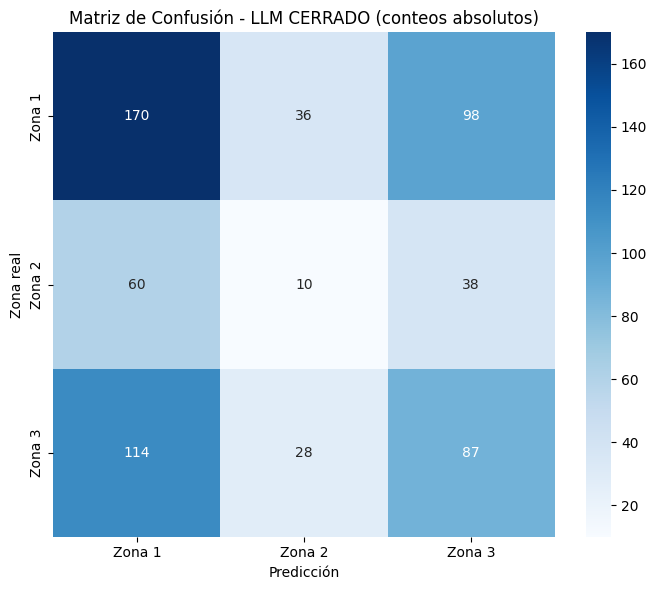

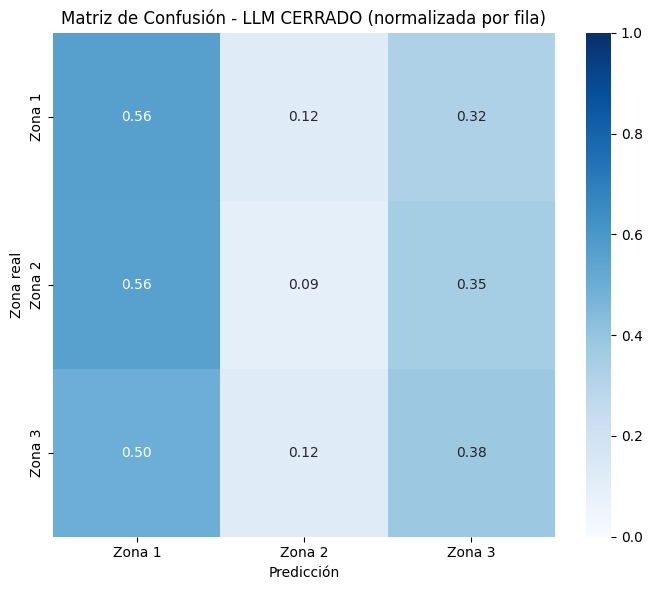

In [8]:
evaluador = EvaluadorResultados()
evaluador.evaluar("predicciones_finales_cerrado.csv", "cerrado")

RESULTADOS PROMPT ABIERTO 2 VLM + PROMPT 1 LLM con QWEN3.5


 EVALUACION MULTICLASE (ZONAS 1, 2 Y 3) 
Muestras evaluadas:           636
Accuracy:                     38.21%
Balanced accuracy:            37.11%
Precision macro:              38.96%
Recall macro:                 37.11%
F1 macro:                     34.72%
F1 weighted:                  38.59%
Predicciones no válidas:      5

Resumen detallado de las predicciones:
      vid_ID kicker_foot  zona_real prediccion_etiqueta  prediccion_numero  acierto
  v1_p1_diag     derecha          1             CRUZADO                  1     True
  v1_p2_diag     derecha          1             CRUZADO                  1     True
  v1_p3_diag     derecha          2             CENTRAL                  2     True
  v1_p4_diag     derecha          3             CRUZADO                  1    False
  v1_p5_diag     derecha          1             CRUZADO                  1     True
  v1_p6_diag     derecha          1             CENTRAL                  2    False
  v1_p7_diag     derecha          3       

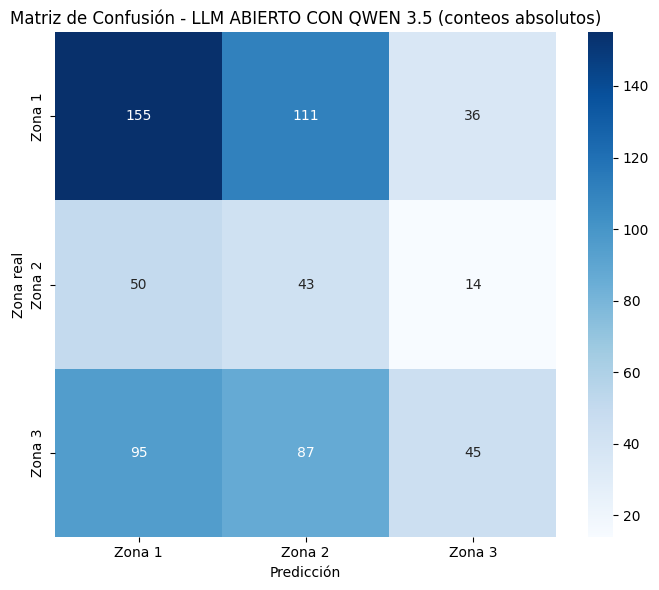

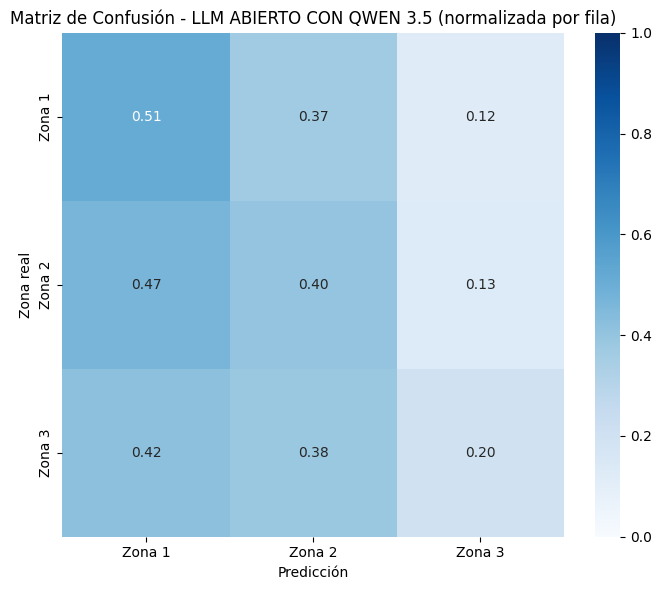

In [11]:
evaluador = EvaluadorResultados()
evaluador.evaluar("predicciones_finales_abierto2_Q6_qwen3.5.csv", "abierto con QWEN 3.5")

PROMPT ABIERTO 2 VLM + PROMPT 1 LLM con llama.


 EVALUACION MULTICLASE (ZONAS 1, 2 Y 3) 
Muestras evaluadas:           641
Accuracy:                     50.08%
Balanced accuracy:            37.82%
Precision macro:              32.82%
Recall macro:                 37.82%
F1 macro:                     33.73%
F1 weighted:                  43.55%

Resumen detallado de las predicciones:
      vid_ID kicker_foot  zona_real prediccion_etiqueta  prediccion_numero  acierto
  v1_p1_diag     derecha          1             CRUZADO                  1     True
  v1_p2_diag     derecha          1             CRUZADO                  1     True
  v1_p3_diag     derecha          2             CRUZADO                  1    False
  v1_p4_diag     derecha          3             CRUZADO                  1    False
  v1_p5_diag     derecha          1             CRUZADO                  1     True
  v1_p6_diag     derecha          1             ABIERTO                  3    False
  v1_p7_diag     derecha          3             CRUZADO                  1

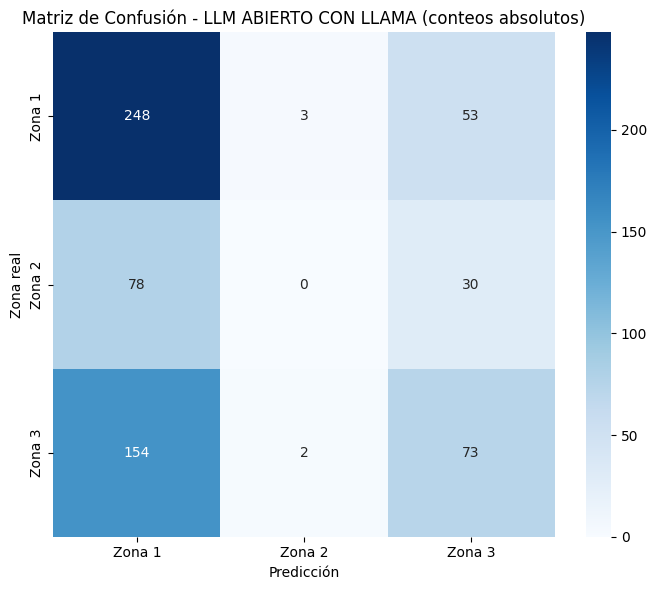

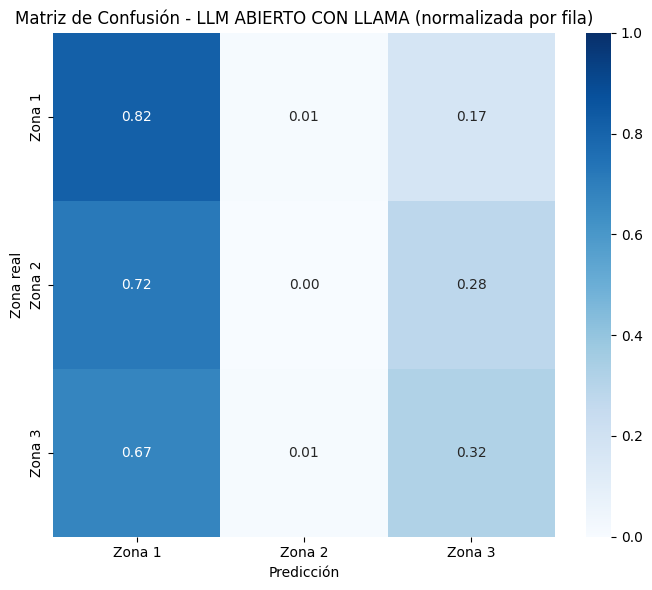

In [12]:
evaluador = EvaluadorResultados()
evaluador.evaluar("predicciones_finales_abierto2_Q6_llama.CSV", "abierto con Llama")

PROMPT ABIERTO 1 VLM + PROMPT 1 LLM con QWEN3.5


 EVALUACION MULTICLASE (ZONAS 1, 2 Y 3) 
Muestras evaluadas:           641
Accuracy:                     17.94%
Balanced accuracy:            31.01%
Precision macro:              29.29%
Recall macro:                 31.01%
F1 macro:                     14.08%
F1 weighted:                  11.17%

Resumen detallado de las predicciones:
      vid_ID kicker_foot  zona_real prediccion_etiqueta  prediccion_numero  acierto
  v1_p1_diag     derecha          1             CENTRAL                  2    False
  v1_p2_diag     derecha          1             CENTRAL                  2    False
  v1_p3_diag     derecha          2             CENTRAL                  2     True
  v1_p4_diag     derecha          3             CENTRAL                  2    False
  v1_p5_diag     derecha          1             CENTRAL                  2    False
  v1_p6_diag     derecha          1             CENTRAL                  2    False
  v1_p7_diag     derecha          3             CENTRAL                  2

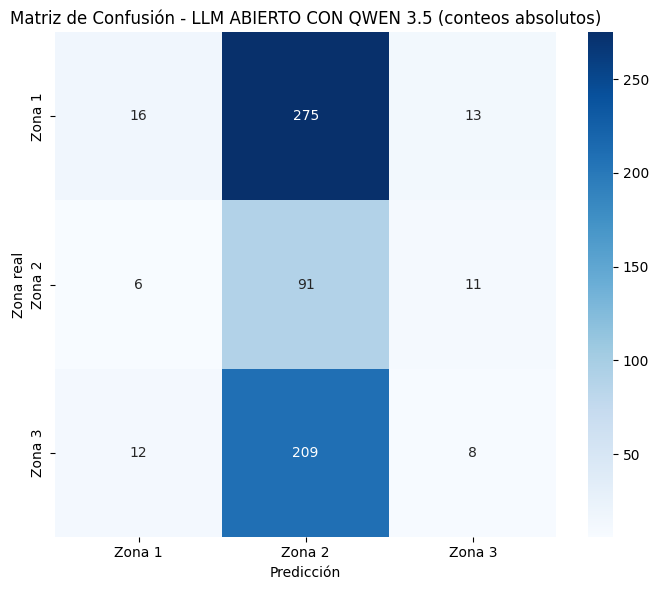

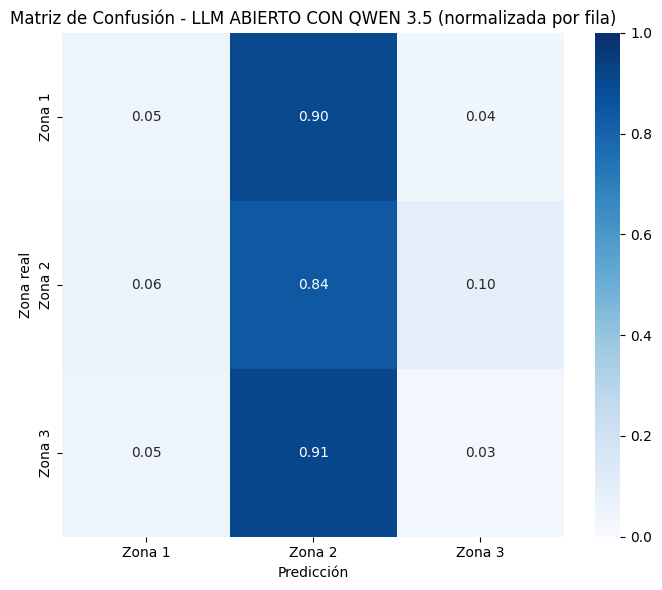

In [13]:
evaluador = EvaluadorResultados()
evaluador.evaluar("predicciones_finales_abierto1_Q6_qwen.CSV", "abierto con Qwen 3.5")

RESULTADOS PROMPT ABIERTO 2 VLM + PROMPT LLM OPTIMIZADA CON LLAMA


 EVALUACION MULTICLASE (ZONAS 1, 2 Y 3) 
Muestras evaluadas:           637
Accuracy:                     45.84%
Balanced accuracy:            36.45%
Precision macro:              36.23%
Recall macro:                 36.45%
F1 macro:                     35.33%
F1 weighted:                  43.07%
Predicciones no válidas:      4

Resumen detallado de las predicciones:
      vid_ID kicker_foot  zona_real prediccion_etiqueta  prediccion_numero  acierto
  v1_p1_diag     derecha          1             CRUZADO                  1     True
  v1_p2_diag     derecha          1             CENTRAL                  2    False
  v1_p3_diag     derecha          2             CENTRAL                  2     True
  v1_p4_diag     derecha          3             CENTRAL                  2    False
  v1_p5_diag     derecha          1             CRUZADO                  1     True
  v1_p6_diag     derecha          1             CRUZADO                  1     True
  v1_p7_diag     derecha          3       

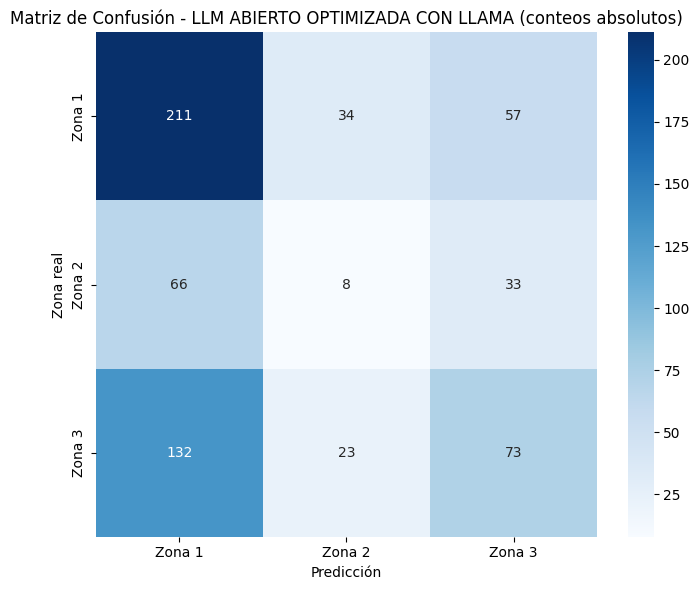

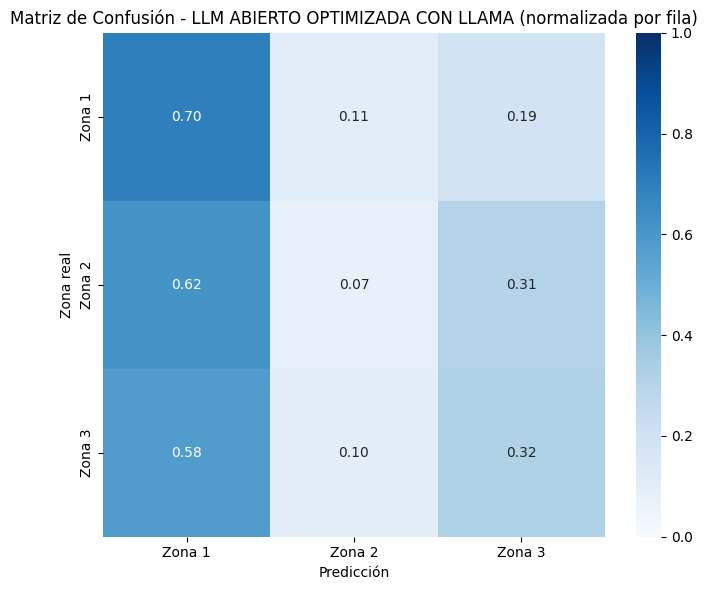

In [15]:
evaluador = EvaluadorResultados()
evaluador.evaluar("predicciones_finales_llama_temperatura0_final.CSV", "abierto optimizada con Llama")

RESULTADOS PROMPT ABIERTO 2 VLM + PROMPT LLM OPTIMIZADA CON QWEN 3.5


 EVALUACION MULTICLASE (ZONAS 1, 2 Y 3) 
Muestras evaluadas:           641
Accuracy:                     48.99%
Balanced accuracy:            37.70%
Precision macro:              36.08%
Recall macro:                 37.70%
F1 macro:                     34.74%
F1 weighted:                  43.94%

Resumen detallado de las predicciones:
      vid_ID kicker_foot  zona_real prediccion_etiqueta  prediccion_numero  acierto
  v1_p1_diag     derecha          1             CRUZADO                  1     True
  v1_p2_diag     derecha          1             CRUZADO                  1     True
  v1_p3_diag     derecha          2             CRUZADO                  1    False
  v1_p4_diag     derecha          3             CENTRAL                  2    False
  v1_p5_diag     derecha          1             CRUZADO                  1     True
  v1_p6_diag     derecha          1             CRUZADO                  1     True
  v1_p7_diag     derecha          3             CRUZADO                  1

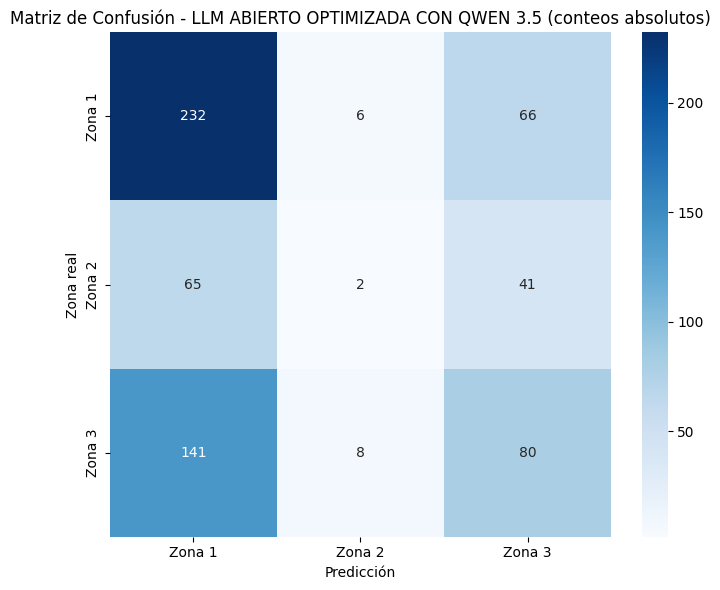

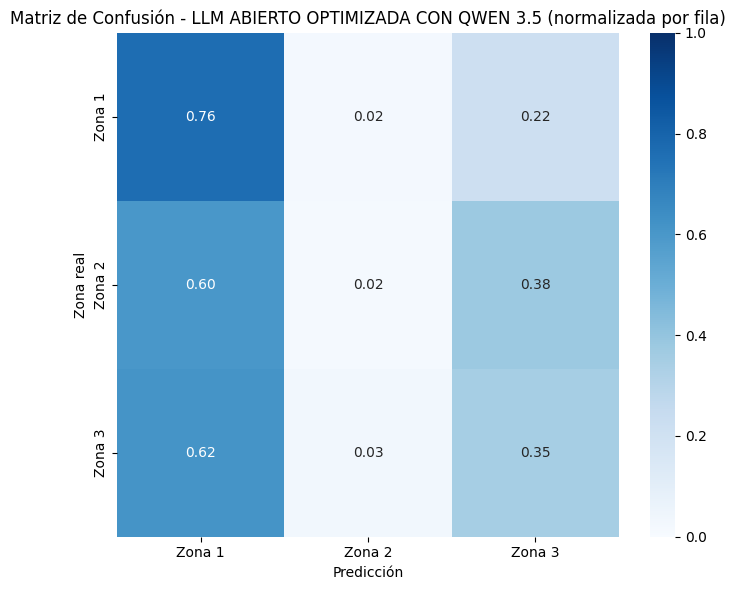

In [17]:
evaluador = EvaluadorResultados()
evaluador.evaluar("predicciones_finales_qwen3.5_final.CSV", "abierto optimizada con QWEN 3.5")